### Load environ

In [20]:
'''
We test the workflow with mpds-S1214986 (mc3d-74668) simple cubit Sb.
'''

from aiida import load_profile, orm, engine

import yaml

from aiida_quantumespresso.workflows.pw.base import PwBaseWorkChain
from aiida_quantumespresso.workflows.pw.relax import PwRelaxWorkChain
from aiida_quantumespresso.workflows.ph.base import PhBaseWorkChain
from aiida_quantumespresso.workflows.q2r.base import Q2rBaseWorkChain
from aiida_quantumespresso.workflows.matdyn.base import MatdynBaseWorkChain
from aiida_quantumespresso.calculations.functions.seekpath_structure_analysis import seekpath_structure_analysis

from aiida_analyser import *
from aiida.tools import delete_nodes

from aiida.common import NotExistent
from pathlib import Path
import time
import numpy
import io
import f90nml

load_profile('ductility', allow_switch=True)

top_workdir = Path('/gpfs/scratch/acad/elph/yimzhang/aiida_workdir/ductility/born/check_q_convergence_new')
data_dir = Path('/home/yimzhang/Development/aiida/ductility/data/elastic/born/check_q_convergence_new')

lucia = orm.load_computer('lucia')
lucia.set_workdir(top_workdir.as_posix())

In [21]:
prepend_text_mn5 = """
    module load oneapi/2023.2
    module load libxc/6.2.0
    module load hdf5/1.14.1-2
"""

prepend_text_lucia = """
ml EasyBuild/2024a Cray/24.07 PrgEnv-intel
"""

def install_codes(
    prepend_text,
    version,
    computer_label,
    bin_dir,
):
    computer = orm.load_computer(computer_label)
    for code in (
        'pw',
        'ph',
        'q2r',
        'matdyn',
    ):
        label = f'{version}-{code}'
        try:
            orm.load_code(f'{label}@{computer_label}')
        except NotExistent as exc:
            orm.InstalledCode(
                label=label,
                description=f'Quantum ESPRESSO {version} version for {code}.x',
                computer=computer,
                filepath_executable=f'{bin_dir}/bin/{code}.x',
                default_calc_job_plugin=f'quantumespresso.{code}',
                prepend_text=prepend_text,
            ).store()

def load_codes(
    version,
    computer_label,
    overrides_path,
):
    codes = {
        "pw": orm.load_code(f'{version}-pw@{computer_label}'),
        "ph": orm.load_code(f'{version}-ph@{computer_label}'),
        "q2r": orm.load_code(f'{version}-q2r@{computer_label}'),
        "matdyn": orm.load_code(f'{version}-matdyn@{computer_label}'),
    }

    with open(overrides_path, 'r') as f:

        overrides_yaml = f.read()

        overrides = yaml.safe_load(overrides_yaml)

    return codes, overrides

install_codes(
    prepend_text_lucia,
    version = 'qe-elastic',
    computer_label = 'lucia',
    bin_dir = '/gpfs/home/acad/ucl-modl/yimzhang/qe-elastic'
)


codes, overrides = load_codes(
    version = 'qe-elastic',
    computer_label = 'lucia',
    overrides_path = '/home/yimzhang/Development/aiida/ductility/code/born/born.yaml',
)



In [22]:

structures_to_check_group, _ = orm.Group.collection.get_or_create(
    label='ductility/born/structures/check_q_convergence'
)
pw_group, _ = orm.Group.collection.get_or_create(
    'ductility/born/workchains/check_q_convergence_new/pw-relax'
)

ph_group, _ = orm.Group.collection.get_or_create(
    'ductility/born/workchains/check_q_convergence_new/ph-base'
)

# ph_rerun_group, _ = orm.Group.collection.get_or_create(
#     'ductility/born/workchains/check_q_convergence_new/ph-base/rerun'
# )

q2r_group, _ = orm.Group.collection.get_or_create(
    'ductility/born/workchains/check_q_convergence_new/q2r-base'
)

matdyn_group, _ = orm.Group.collection.get_or_create(
    'ductility/born/workchains/check_q_convergence_new/matdyn-base'
)


In [23]:
unstable = ['mpds-S1503730', 'mpds-S301111', 'mpds-S549446', 'mpds-S551694']
not_converged = ['mpds-S1412199', 'mpds-S547970', 'mpds-S1251782']

In [24]:
from aiida.storage.sqlite_zip.backend import SqliteZipBackend
from pathlib import Path
from util import *

archive_profile = load_profile('ductility', allow_switch=True)
fd = update_modulus_from_fd(archive_profile, 'ductility/thermo_pw/v3')

298


load from calculation

In [25]:
born = NestedDict()

In [26]:
# def parse_matdyn_output(retrieved):
#     f = io.StringIO(retrieved.get_object_content('matdyn.elastic.yaml'))
#     data = yaml.safe_load(f)
#     f.close()
#     return data


# for matdyn_wc in matdyn_group.nodes:
#     ph_calculation = matdyn_wc.inputs.matdyn.force_constants.creator.inputs.parent_folder.creator
#     qpoints_distance = ph_calculation.caller.inputs.qpoints_distance.value
#     nq = numpy.prod(ph_calculation.inputs.qpoints.get_kpoints_mesh()[0])
#     extra = matdyn_wc.base.extras.all
#     source = f"{extra['source_db']}-{extra['source_id']}"
#     if source not in born:
#         born[source] = {}
#     if qpoints_distance not in born[source]:
#         born[source][qpoints_distance] = {
#             "nq": nq,
#             "elastic_constants": [],
#             "voigt_average": {},
#             "reuss_average": {},
#             "VRH_average": {},
#         }

#     matdyn_dict = parse_matdyn_output(matdyn_wc.outputs.retrieved)
#     elastic_constants = numpy.array(matdyn_dict.get("elastic_constants"))
#     born[source][qpoints_distance]['phonon_bands'] = matdyn_wc.outputs.output_phonon_bands
#     born[source][qpoints_distance]['seekpath_parameters'] = matdyn_wc.inputs.matdyn.kpoints.creator.outputs.parameters
#     born[source][qpoints_distance]["elastic_constants"] = elastic_constants
#     born[source][qpoints_distance]["voigt_average"] = matdyn_dict.get("voigt_average")
#     born[source][qpoints_distance]["reuss_average"] = matdyn_dict.get("reuss_average")
#     born[source][qpoints_distance]["VRH_average"] = matdyn_dict.get("VRH_average")
#     for average in ['voigt_average', 'reuss_average', 'VRH_average']:
#         bulk_modulus = born[source][qpoints_distance][average]["bulk_modulus"]
#         young_modulus = born[source][qpoints_distance][average]["young_modulus"]
#         pettifor_ratio = (born[source][qpoints_distance]["elastic_constants"][0][1] - born[source][qpoints_distance]["elastic_constants"][3][3]) / young_modulus
#         modified_pettifor_ratio = (elastic_constants[0][1] - elastic_constants[3][3]) / bulk_modulus
#         pugh_ratio = 1 / born[source][qpoints_distance][average]["pugh_ratio"]
#         born[source][qpoints_distance][average]["pugh_ratio"] = pugh_ratio
#         born[source][qpoints_distance][average]["pettifor_ratio"] = pettifor_ratio
#         born[source][qpoints_distance][average]["modified_pettifor_ratio"] = modified_pettifor_ratio

In [27]:

for wc in ph_group.nodes:
    extras = wc.base.extras.all
    source = f"{extras['source_db']}-{extras['source_id']}"
    qpoints_distance = wc.inputs.qpoints_distance.value
    if wc.process_state.value == 'waiting':
        print(source, qpoints_distance)
        born[source][qpoints_distance]['status'] = f'waiting at ph_base {wc.pk}'


load from folder

In [28]:
structures_to_check = {}
for node in structures_to_check_group.nodes:
    extras = node.base.extras.all
    source = f"{extras['source_db']}-{extras['source_id']}"
    structures_to_check[source] = node

for path in data_dir.glob('*'):
    if path.is_dir():
        source = path.name
        for subpath in path.glob('*'):
            if subpath.is_dir():

                subpath_name = subpath.name

                if subpath_name == 'pw_base':
                    continue

                qpoints_distance = float(subpath_name)
                ph_base_input_path = subpath / 'ph_base' / 'iteration_01' / 'aiida.in'
                matdyn_base_path = subpath / 'matdyn_base' / 'iteration_01' / 'matdyn.elastic.yaml'

                if ph_base_input_path.exists():
                    ph_input = f90nml.read(ph_base_input_path.as_posix())
                    number_of_qpoints = ph_input['INPUTPH']['nq1'] * ph_input['INPUTPH']['nq2'] * ph_input['INPUTPH']['nq3']
                    born[source][qpoints_distance]['q_mesh'] = [ph_input['INPUTPH']['nq1'], ph_input['INPUTPH']['nq2'], ph_input['INPUTPH']['nq3']]
                    born[source][qpoints_distance]['number_of_qpoints'] = number_of_qpoints

                if matdyn_base_path.exists() and ph_base_input_path.exists():

                    yaml_content = matdyn_base_path.read_text()
                    yaml_dict = yaml.safe_load(yaml_content)
                    born[source][qpoints_distance] = yaml_dict
                    born[source][qpoints_distance]['status'] = 'finished at matdyn_base'

                    ph_input = f90nml.read(ph_base_input_path.as_posix())
                    number_of_qpoints = ph_input['INPUTPH']['nq1'] * ph_input['INPUTPH']['nq2'] * ph_input['INPUTPH']['nq3']
                    born[source][qpoints_distance]['q_mesh'] = [ph_input['INPUTPH']['nq1'], ph_input['INPUTPH']['nq2'], ph_input['INPUTPH']['nq3']]
                    born[source][qpoints_distance]['number_of_qpoints'] = number_of_qpoints

                    elastic_constants = numpy.array(born[source][qpoints_distance].get("elastic_constants"))
                    for average in ['voigt_average', 'reuss_average', 'VRH_average']:
                        bulk_modulus = born[source][qpoints_distance][average]["bulk_modulus"]
                        young_modulus = born[source][qpoints_distance][average]["young_modulus"]
                        pettifor_ratio = (elastic_constants[0][1] - elastic_constants[3][3]) / young_modulus
                        modified_pettifor_ratio = (elastic_constants[0][1] - elastic_constants[3][3]) / bulk_modulus
                        pugh_ratio = 1 / born[source][qpoints_distance][average]["pugh_ratio"]
                        born[source][qpoints_distance][average]["pugh_ratio"] = pugh_ratio
                        born[source][qpoints_distance][average]["pettifor_ratio"] = pettifor_ratio
                        born[source][qpoints_distance][average]["modified_pettifor_ratio"] = modified_pettifor_ratio

In [29]:
born

NestedDict({'mpds-S534147': NestedDict({0.2: {'dimension': '3D', 'elastic_unit': 'GPa', 'velocity_unit': 'km/s', 'temperature_unit': 'K', 'kappa_unit': 'W/mK', 'density_unit': 'kg/m^3', 'elastic_constants': [[721.2927009, 119.3010462, 119.3010462, 0.0, 0.0, 0.0], [119.3010462, 721.2922244, 119.3010133, 0.0, 0.0, 0.0], [119.3010462, 119.3010133, 721.2922244, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 181.6302011, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 181.6301589, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 181.6301589]], 'elastic_compliances': [[0.001454695386, -0.0002064573848, -0.0002064573848, 0.0, 0.0, 0.0], [-0.0002064573848, 0.001454696351, -0.0002064574686, 0.0, 0.0, 0.0], [-0.0002064573848, -0.0002064574686, 0.001454696351, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.005505692303, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.00550569358, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.00550569358]], 'voigt_average': {'bulk_modulus': 319.964818, 'shear_modulus': 229.376373, 'young_modulus': 555.408668, 'poisson_ratio': 0.210693, 'p_wave_modul

In [30]:
import pandas as pd
import numpy as np

# 1. 定义符号
CHECK_MARK = '✔'  # 或 'DONE'
CROSS_MARK = '✘'  # 或 'TODO'
flattened_list = []

if isinstance(born, NestedDict):
    born = born.to_dict()
for source_id, q_dict in born.items():
    for q_dist, res_content in q_dict.items():
        # status = res_content.get('status', None)
        flattened_list.append({
            'source': source_id,
            'qpoints_distance': q_dist,
            'q_mesh': res_content.get('q_mesh', None),
            'status': res_content.get('status', None)
        })

for source_id in structures_to_check:
    if source_id not in born:
        flattened_list.append({
            'source': source_id,
            'status': False
        })

df = pd.DataFrame(flattened_list)
pivot_df = df.pivot(index='source', columns='qpoints_distance', values='status')

pivot_df = pivot_df.fillna(False)

def color_red_index(index_label):
    if index_label in structures_to_check:
        # 返回 CSS 样式字符串
        return 'color: red; font-weight: bold;'
    else:
        # 不改变样式
        return ''

def mark_map(x):
    if x == False:
        return 'TODO'
    elif x == 'finished at matdyn_base':
        return CHECK_MARK
    elif x.startswith('waiting at ph_base'):
        return x
    else:
        return 'unknown'

final_table = pivot_df.map(mark_map)
final_table = final_table.sort_index(axis=1)

styled_df = final_table.style.map_index(color_red_index, axis=0)


In [31]:
from typing import Tuple
def create_xticks(seekpath_params):
    """Create xticks and xtick_labels for a band structure plot from the Seek-path parameters."""

    def transform_gamma(label):
        import re
        pattern = r'(?<!\$)([A-Za-z]+_\d+)'
        replacement = r'$\1$'
        if label == 'GAMMA':
            return r'$\Gamma$'
        return re.sub(pattern, replacement, label)

    path = seekpath_params['path']
    xtick_labels = [transform_gamma(path[0][0]), ]

    for segment_number, segment_labels in enumerate(path):
        try:
            if segment_labels[1] == path[segment_number + 1][0]:
                xtick_labels.append(transform_gamma(segment_labels[1]))
            else:
                xtick_labels.append(f'{transform_gamma(segment_labels[1])}|{transform_gamma(path[segment_number + 1][0])}')
        except IndexError:
            xtick_labels.append(transform_gamma(segment_labels[1]))

    explicit_segments = seekpath_params['explicit_segments']
    xticks = [explicit_segments[0][0]]

    for explicit_segment in explicit_segments:
        xticks.append(explicit_segment[1])

    return xticks, xtick_labels

def create_xticks_bands(bands: orm.BandsData) -> Tuple[list, list]:
    """Create xticks and xtick_labels for a band structure plot.

    Takes a BandsData object and returns a tuple of xticks and xtick_labels. The script takes care
    of two things:

    1. If the last label of a segment is not the same as the first label of the next segment, a
       vertical line is added between the two symmetry point labels.
    2. In case the label is "GAMMA", it is replaced with the greek capital letter gamma, as is the
       convention.

    """
    def transform_gamma(label):
        import re
        pattern = r'(?<!\$)([A-Za-z]+_\d+)'
        replacement = r'$\1$'
        if label == 'GAMMA':
            return r'$\Gamma$'
        return re.sub(pattern, replacement, label)

    labels = bands.base.attributes.all['labels']
    label_numbers = bands.base.attributes.all['label_numbers']

    xticks = [label_numbers[0], ]
    xtick_labels = [transform_gamma(labels[0]), ]

    for label, label_number in zip(labels[1:], label_numbers[1:]):

        if label_number - xticks[-1] == 1:
            xtick_labels.append(f'{transform_gamma(xtick_labels.pop())}|{transform_gamma(label)}')
        else:
            xtick_labels.append(transform_gamma(label))
            xticks.append(label_number)

    return xticks, xtick_labels

def plot_bands(bands: orm.BandsData, axis=None, reference_energy=0, seekpath_params=None, **kwargs):
    """Plot a band structure from a ``BandsData`` node."""

    color = kwargs.pop('color', 'blue')
    ylim = kwargs.pop(
        'ylim',
        [bands.get_bands().min() - reference_energy, bands.get_bands().max() - reference_energy]
        )
    label = kwargs.pop('label', None)
    tick_label_size = kwargs.pop('tick_label_size', 16)

    if axis is None:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(1, 1, figsize=(8, 6), sharex=True)
        fig.patch.set_facecolor('white')
    else:
        ax = axis

    if seekpath_params is not None:
        xticks, xtick_labels = create_xticks(seekpath_params)
    else:
        try:
            xticks, xtick_labels = create_xticks_bands(bands)
        except IndexError:
            xticks = []
            xtick_labels = []

    if len(xticks) > 0:
        ax.set_xticks(xticks, xtick_labels, fontsize=tick_label_size)
    xlim = kwargs.pop('xlim', [xticks[0], xticks[-1]])
    for tick in xticks:
        ax.axvline(tick, color='k')

    for band in bands.get_bands().transpose():
        ax.plot(band - reference_energy, color=color, **kwargs)

    ax.plot([], [], color=color, label=label)

    ax.axhline(0, color='k', linestyle='--')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    if axis is None:
        return plt


In [32]:
from pymatgen.core import Composition

formulae = {}
scon_group = orm.Group.collection.get(label='paper/structures/scon')
for structure in scon_group.nodes:
    extras = structure.base.extras.all
    formula = structure.get_formula()
    comp = Composition(formula)
    # if formula in ['HfN', 'CTa']:
    #     print(structure.base.extras.all)
    formulae[f"{extras['source_db']}-{extras['source_id']}"] = comp.get_reduced_formula_and_factor(iupac_ordering=True)[0]

In [33]:
import re

def formula_to_latex(formula):
    latex_formula = re.sub(r'(\d+)', r'_{\1}', formula)
    return rf"${latex_formula}$"

### Run pw workchains

In [18]:
scon_group = orm.Group.collection.get(label='paper/structures/scon')
for structure in scon_group.nodes:
    formula = structure.get_formula()
    if formula in ['HfN', 'CTa']:
        print(structure.base.extras.all)
#         structures_to_check_group.add_nodes(structure)

{'source': {'id': 'S534147', 'version': '1.0.0', 'database': 'mpds'}, 'source_db': 'mpds', 'source_id': 'S534147', 'duplicates': [], 'formula_hill': 'CTa', 'magnetization': [0.0, 0.0], 'bravais_lattice': 'cF', 'chemical_system': '-C-Ta-', 'number_of_sites': 2, 'spacegroup_number': 225, 'partial_occupancies': False, 'formula_hill_compact': 'CTa', 'bravais_lattice_extended': 'cF2', 'spacegroup_international': 'Fm-3m'}
{'source': {'id': 'S1923735', 'version': '1.0.0', 'database': 'mpds'}, 'source_db': 'mpds', 'source_id': 'S1923735', 'duplicates': [], 'formula_hill': 'HfN', 'magnetization': [0.0, 0.0], 'bravais_lattice': 'cF', 'chemical_system': '-Hf-N-', 'number_of_sites': 2, 'spacegroup_number': 225, 'partial_occupancies': False, 'formula_hill_compact': 'HfN', 'bravais_lattice_extended': 'cF2', 'spacegroup_international': 'Fm-3m'}


In [15]:
qb = orm.QueryBuilder()
qb.append(
    orm.Group,
    filters={'label': 'ductility/born/workchains/check_q_convergence_new/pw-relax'},
    tag='pw_group'
    ).append(
    orm.WorkChainNode,
    with_group='pw_group',
    tag='pw_wc',
    project=['extras.source_db', 'extras.source_id', "*"]
)

pw_already_done = {}

for source_db, source_id, wc in qb.iterall():

    source = f"{source_db}-{source_id}"
    if source not in pw_already_done:
        pw_already_done[source] = wc
    try:
        analyser = PwBaseWorkChainAnalyser(wc)
        analyser.copy_tree(data_dir / f'{source_db}-{source_id}/pw_base')
    except Exception as e:
        print(e)
print(pw_already_done)

Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/elastic/born/check_q_convergence_new/mpds-S549446/pw_base
Extraction complete.
Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/elastic/born/check_q_convergence_new/icsd-200101/pw_base
Extraction complete.
Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/elastic/born/check_q_convergence_new/mpds-S1251782/pw_base
Extraction complete.
Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/elastic/born/check_q_convergence_new/mpds-S301111/pw_base
Extraction complete.
Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/elastic/born/check_q_convergence_new/mpds-S551694/pw_base
Extraction complete.
Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/elastic/born/check_q_convergence_new/mpds-S1503730/pw_base
Extraction complete.
Starting extraction to directory:

In [16]:
count_submission = 0
number_to_submit = 10

for structure in structures_to_check_group.nodes:
    if count_submission >= number_to_submit:
        break
    extras = structure.base.extras.all
    source = f"{extras['source_db']}-{extras['source_id']}"
    if source in pw_already_done:
        continue

    builder = PwRelaxWorkChain.get_builder_from_protocol(
        code=codes['pw'],
        structure=structure,
        overrides=overrides.get("relax"),
        )

    builder.clean_workdir = orm.Bool(False)

    print('Submiting:', extras)
    pw_workchain = engine.submit(builder)
    pw_workchain.base.extras.set_many(extras)
    pw_group.add_nodes(pw_workchain)
    count_submission += 1
    time.sleep(0.5)

/home/yimzhang/Software/apps/miniconda3/envs/aiida264/lib/python3.11/site-packages/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: base_relax.pseudo_family
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Software/apps/miniconda3/envs/aiida264/lib/python3.11/site-packages/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: base_init_relax.pseudo_family
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')


Submiting: {'source': {'id': 'S534147', 'version': '1.0.0', 'database': 'mpds'}, 'source_db': 'mpds', 'source_id': 'S534147', 'duplicates': [], 'formula_hill': 'CTa', 'magnetization': [0.0, 0.0], 'bravais_lattice': 'cF', 'chemical_system': '-C-Ta-', 'number_of_sites': 2, 'spacegroup_number': 225, 'partial_occupancies': False, 'formula_hill_compact': 'CTa', 'bravais_lattice_extended': 'cF2', 'spacegroup_international': 'Fm-3m'}


/home/yimzhang/Software/apps/miniconda3/envs/aiida264/lib/python3.11/site-packages/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: base_relax.pseudo_family
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Software/apps/miniconda3/envs/aiida264/lib/python3.11/site-packages/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: base_init_relax.pseudo_family
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')


Submiting: {'source': {'id': 'S1923735', 'version': '1.0.0', 'database': 'mpds'}, 'source_db': 'mpds', 'source_id': 'S1923735', 'duplicates': [], 'formula_hill': 'HfN', 'magnetization': [0.0, 0.0], 'bravais_lattice': 'cF', 'chemical_system': '-Hf-N-', 'number_of_sites': 2, 'spacegroup_number': 225, 'partial_occupancies': False, 'formula_hill_compact': 'HfN', 'bravais_lattice_extended': 'cF2', 'spacegroup_international': 'Fm-3m'}


In [ ]:
qb = orm.QueryBuilder()
qb.append(
    orm.Group,
    filters={'label': 'ductility/born/workchains/check_q_convergence_new/ph-base'},
    tag='pw_group'
    ).append(
    orm.WorkChainNode,
    with_group='pw_group',
    tag='pw_wc',
    project=['extras.source_db', 'extras.source_id', "*"]
)

ph_already_done = {}

for source_db, source_id, wc in qb.iterall():
    source = f"{source_db}-{source_id}"
    if source not in ph_already_done:
        ph_already_done[source] = wc
print(ph_already_done)

In [ ]:
qb = orm.QueryBuilder()
qb.append(
    orm.Group,
    filters={'label': 'ductility/born/workchains/check_q_convergence/ph-base'},
    tag='pw_group'
    ).append(
    orm.WorkChainNode,
    with_group='pw_group',
    tag='pw_wc',
    project=['extras.source_db', 'extras.source_id', "*"]
)

ph_already_done = {}

for source_db, source_id, wc in qb.iterall():
    source = f"{source_db}-{source_id}"
    if source not in ph_already_done:
        ph_already_done[source] = wc
print(ph_already_done)

### Run ph workchains

In [34]:
qb = orm.QueryBuilder()
qb.append(
    orm.Group,
    filters={'label': 'ductility/born/workchains/check_q_convergence_new/ph-base'},
    tag='pw_group'
    ).append(
    orm.WorkChainNode,
    with_group='pw_group',
    tag='pw_wc',
    project=['extras.source_db', 'extras.source_id', "*"]
)

ph_already_done = {}
for d in flattened_list:
    if d.get('source', None) and d.get('q_mesh', None) and d.get('status', None):
        q_mesh_str = '-'.join(map(str, d['q_mesh']))
        ph_already_done[f"{d['source']}-{q_mesh_str}"] = d['status']

for source_db, source_id, wc in qb.iterall():
    analyser = PhBaseWorkChainAnalyser(wc)
    iteration_01 = analyser.process_tree.iteration_01.node
    qpoints = '-'.join(map(str, iteration_01.inputs.qpoints.get_kpoints_mesh()[0]))
    source = f"{source_db}-{source_id}-{qpoints}"
    if source not in ph_already_done:
        ph_already_done[source] = wc

    # try:
    #     analyser = PhBaseWorkChainAnalyser(wc)
    #     analyser.copy_tree(data_dir / f'{source_db}-{source_id}/{wc.inputs.qpoints_distance.value}/ph_base')
    # except Exception as e:
    #     print(e)

print(len(ph_already_done))
ph_already_done

55


{'mpds-S534147-13-13-13': 'finished at matdyn_base',
 'mpds-S534147-9-9-9': 'finished at matdyn_base',
 'mpds-S534147-5-5-5': 'finished at matdyn_base',
 'mpds-S534147-10-10-10': 'finished at matdyn_base',
 'mpds-S534147-4-4-4': 'finished at matdyn_base',
 'mpds-S534147-3-3-3': 'finished at matdyn_base',
 'mpds-S534147-7-7-7': 'finished at matdyn_base',
 'mpds-S1830331-6-6-6': 'finished at matdyn_base',
 'mpds-S1830331-4-4-4': 'finished at matdyn_base',
 'mpds-S1830331-7-7-7': 'finished at matdyn_base',
 'mpds-S1830331-3-3-3': 'finished at matdyn_base',
 'mpds-S1830331-2-2-2': 'finished at matdyn_base',
 'mpds-S551694-2-2-1': 'finished at matdyn_base',
 'mpds-S547970-8-8-2': 'finished at matdyn_base',
 'mpds-S547970-5-5-1': 'finished at matdyn_base',
 'mpds-S547970-9-9-2': 'finished at matdyn_base',
 'mpds-S547970-4-4-1': 'finished at matdyn_base',
 'mpds-S547970-3-3-1': 'finished at matdyn_base',
 'mpds-S549446-2-2-2': 'finished at matdyn_base',
 'mpds-S1503730-2-2-2': 'finished at ma

In [38]:
from aiida_quantumespresso.calculations.functions.create_kpoints_from_distance import create_kpoints_from_distance

count_submission = 0
number_to_submit = 10
qpoints_distance = 0.2

for parent_wc in pw_group.nodes:
    if not parent_wc.is_finished_ok:
        continue
    if count_submission >= number_to_submit:
        break

    extras = parent_wc.base.extras.all

    if f"{extras['source_db']}-{extras['source_id']}" in unstable:
        continue

    if f"{extras['source_db']}-{extras['source_id']}" not in ['mpds-S1830331']:
        continue
    structure = parent_wc.outputs.output_structure
    # structure = structures_to_check[f"{extras['source_db']}-{extras['source_id']}"]
    inputs = {
        'structure': structure,
        'distance': qpoints_distance,
        'force_parity': orm.Bool(False),
        'metadata': {
            'call_link_label': 'create_kpoints_from_distance'
        }
    }
    qpoints = create_kpoints_from_distance(**inputs)  # pylint: disable=unexpected-keyword-arg
    q_mesh = qpoints.get_kpoints_mesh()[0]
    q_mesh_str = '-'.join(map(str, q_mesh))

    source = f"{extras['source_db']}-{extras['source_id']}-{q_mesh_str}"

    # if f"{extras['source_db']}-{extras['source_id']}" not in ['mpds-S1412199', 'mpds-S547970']:
    #     continue

    if source in ph_already_done:
        print(source, 'already done')
        continue

    print('Submitting', source)
    builder = PhBaseWorkChain.get_builder_from_protocol(
        codes['ph'],
        protocol=None,
        overrides=overrides['ph_base'],
    )

    builder.clean_workdir = orm.Bool(True)
    builder.qpoints_distance = orm.Float(qpoints_distance)
    builder.ph.parent_folder = parent_wc.outputs.remote_folder

        # dt = DictTree(builder)
        # dt.print()

    ph_workchain = engine.submit(builder)
    ph_workchain.base.extras.set_many(extras)
    ph_group.add_nodes(ph_workchain)
    count_submission += 1
    time.sleep(0.5)

Submitting mpds-S1830331-9-9-9


### RERUN PHBASEWORKCHAIN

In [ ]:
qb = orm.QueryBuilder()
qb.append(
    orm.Group,
    filters={'label': 'ductility/born/workchains/check_q_convergence/ph-base/rerun'},
    tag='ph_rerun_group'
    ).append(
    orm.WorkChainNode,
    with_group='ph_rerun_group',
    tag='ph_rerun_wc',
    project=['extras.source_db', 'extras.source_id', "*"]
)

ph_rerun_already_done = {}

for source_db, source_id, wc in qb.iterall():
    source = f"{source_db}-{source_id}-{wc.inputs.qpoints_distance.value}"
    if source not in ph_rerun_already_done:
        ph_rerun_already_done[source] = wc
    try:
        analyser = PhBaseWorkChainAnalyser(wc)
        analyser.copy_tree(data_dir / f"{extra['source_db']}-{extra['source_id']}/{wc.inputs.qpoints_distance.value}/ph_base")
    except Exception as e:
        print(e)

print(len(ph_rerun_already_done))
ph_rerun_already_done

0


{}

In [ ]:
count_submission = 0
number_to_submit = 10

for pk in [19852, 20012, 20154, 20162, 20193, 20204, 20215]:
    parent_wc = orm.load_node(pk)
    qpoints_distance = parent_wc.inputs.qpoints_distance
    # if not parent_wc.is_finished_ok:
    #     continue
    if count_submission >= number_to_submit:
        break

    extras = parent_wc.base.extras.all
    source = f"{extras['source_db']}-{extras['source_id']}-{qpoints_distance.value}"
    if source in ph_rerun_already_done:
        print(source, 'already done')
        continue

    analyser = PhBaseWorkChainAnalyser(parent_wc)
    iteration_01 = analyser.process_tree.iteration_01.node

    builder = PhBaseWorkChain.get_builder_from_protocol(
        codes['ph'],
        protocol=None,
        overrides=overrides['ph_base'],
    )

    print(iteration_01.inputs.qpoints)
    builder.clean_workdir = orm.Bool(True)
    builder.qpoints = iteration_01.inputs.qpoints
    builder.ph.parent_folder = iteration_01.outputs.remote_folder

        # dt = DictTree(builder)
        # dt.print()

    ph_workchain = engine.submit(builder)
    ph_workchain.base.extras.set_many(extras)
    ph_rerun_group.add_nodes(ph_workchain)
    count_submission += 1
    time.sleep(0.5)

### RUN Q2RBASEWORKCHAIN

In [35]:
qb = orm.QueryBuilder()
qb.append(
    orm.Group,
    filters={'label': "ductility/born/workchains/check_q_convergence_new/q2r-base"},
    tag='q2r_group'
    ).append(
    orm.WorkChainNode,
    with_group='q2r_group',
    # filters={'attributes.exit_status': 0},
    tag='q2r_wc'
)

q2r_already_done = []

for q2r_wc in qb.all(flat=True):
    if not q2r_wc.is_finished_ok:
        continue
    extra = q2r_wc.base.extras.all
    ph_base = q2r_wc.inputs.q2r.parent_folder.creator.caller
    source = f"{extra['source_db']}-{extra['source_id']}-{ph_base.inputs.qpoints_distance.value}"
    if source not in q2r_already_done:
        q2r_already_done.append(source)
    try:
        analyser = Q2rBaseWorkChainAnalyser(q2r_wc)
        analyser.copy_tree(data_dir / f"{extra['source_db']}-{extra['source_id']}/{ph_base.inputs.qpoints_distance.value}/q2r_base")
    except Exception as e:
        print(e)
print(q2r_already_done)


Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/elastic/born/check_q_convergence_new/mpds-S549446/1.0/q2r_base
Extraction complete.
Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/elastic/born/check_q_convergence_new/icsd-200101/1.0/q2r_base
Extraction complete.
Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/elastic/born/check_q_convergence_new/mpds-S1251782/1.0/q2r_base
Extraction complete.
Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/elastic/born/check_q_convergence_new/mpds-S301111/1.0/q2r_base
Extraction complete.
Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/elastic/born/check_q_convergence_new/mpds-S551694/1.0/q2r_base
Extraction complete.
Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/elastic/born/check_q_convergence_new/mpds-S1503730/1.0/q2r_base
Extraction complete.
Sta

In [36]:

count_submit = 0
num_submit = 30

for parent_ph in ph_group.nodes:
    if not parent_ph.is_finished_ok:
        continue
    if count_submit >= num_submit:
        print(f'{count_submit} jobs submitted')
        break

    parent_extras = parent_ph.base.extras.all

    extras = parent_ph.base.extras.all
    source = f"{extras['source_db']}-{extras['source_id']}-{parent_ph.inputs.qpoints_distance.value}"
    if not source:
        print(f'{parent_ph.pk} has no source')
        continue
    if source in q2r_already_done:
        print(source, 'already done')
        continue

    builder = Q2rBaseWorkChain.get_builder()

    builder.q2r.metadata = overrides['q2r_base']['q2r']['metadata']
    builder.q2r.parameters = orm.Dict(overrides['q2r_base']['q2r']['parameters'])

    builder.q2r.parent_folder = parent_ph.outputs.retrieved
    builder.q2r.code = codes['q2r']

    builder.clean_workdir = orm.Bool(True)

        # dt = DictTree(builder)
        # dt.print()

    q2r_wc = engine.submit(builder)
    q2r_wc.base.extras.set_many(parent_extras)
    q2r_group.add_nodes(q2r_wc)

    count_submit += 1
    time.sleep(0.5)

mpds-S549446-1.0 already done
icsd-200101-1.0 already done
mpds-S1251782-1.0 already done
mpds-S301111-1.0 already done
mpds-S551694-1.0 already done
mpds-S1503730-1.0 already done
mpds-S547970-1.0 already done
mpds-S1830331-1.0 already done
mpds-S529575-1.0 already done
mpds-S1412199-1.0 already done
icsd-200101-0.7 already done
mpds-S1251782-0.7 already done
mpds-S547970-0.7 already done
mpds-S1830331-0.7 already done
mpds-S529575-0.7 already done
mpds-S1412199-0.7 already done
icsd-200101-0.5 already done
mpds-S1251782-0.5 already done
mpds-S547970-0.5 already done
mpds-S1830331-0.5 already done
mpds-S529575-0.5 already done
mpds-S1412199-0.5 already done
icsd-200101-0.3 already done
mpds-S1251782-0.3 already done
mpds-S547970-0.3 already done
mpds-S1830331-0.3 already done
mpds-S529575-0.3 already done
mpds-S1412199-0.3 already done
icsd-200101-0.25 already done
mpds-S1251782-0.25 already done
mpds-S547970-0.25 already done
mpds-S1830331-0.25 already done
mpds-S1412199-0.25 already

03/27/2026 10:16:37 AM <3040595> aiida.broker.rabbitmq: [WARNING] RabbitMQ v3.12.1 is not supported and will cause unexpected problems!
03/27/2026 10:16:37 AM <3040595> aiida.broker.rabbitmq: [WARNING] It can cause long-running workflows to crash and jobs to be submitted multiple times.
03/27/2026 10:16:37 AM <3040595> aiida.broker.rabbitmq: [WARNING] See https://github.com/aiidateam/aiida-core/wiki/RabbitMQ-version-to-use for details.


mpds-S1923735-1.0 already done
mpds-S534147-0.7 already done
mpds-S1923735-0.7 already done
mpds-S534147-0.5 already done
mpds-S1923735-0.5 already done
mpds-S534147-0.3 already done
mpds-S1923735-0.3 already done
mpds-S534147-0.4 already done
mpds-S1923735-0.4 already done
mpds-S534147-0.25 already done
mpds-S1923735-0.25 already done
mpds-S534147-0.2 already done
mpds-S1923735-0.2 already done


### RUN MATDYNBASEWORKCHAIN

In [39]:

qb= orm.QueryBuilder()
qb.append(
    orm.Group,
    filters={'label': "ductility/born/workchains/check_q_convergence_new/matdyn-base"},
    tag='matdyn_group'
    ).append(
    orm.WorkChainNode,
    with_group='matdyn_group',
    # filters={'attributes.exit_status': 0},
    tag='matdyn_wc'
)


matdyn_already_done = []

for matdyn_wc in qb.all(flat=True):
    if not matdyn_wc.is_finished_ok:
        continue
    extra = matdyn_wc.base.extras.all
    ph_base = matdyn_wc.inputs.matdyn.force_constants.creator.inputs.parent_folder.creator.caller
    source = f"{extra['source_db']}-{extra['source_id']}-{ph_base.inputs.qpoints_distance.value}"
    if source not in matdyn_already_done:
        matdyn_already_done.append(source)
    try:
        analyser = MatdynBaseWorkChainAnalyser(matdyn_wc)
        analyser.copy_tree(data_dir / f"{extra['source_db']}-{extra['source_id']}/{ph_base.inputs.qpoints_distance.value}/matdyn_base")
    except Exception as e:
        print(e)
print(matdyn_already_done)


Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/elastic/born/check_q_convergence_new/mpds-S549446/1.0/matdyn_base
Extraction complete.
Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/elastic/born/check_q_convergence_new/icsd-200101/1.0/matdyn_base
Extraction complete.
Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/elastic/born/check_q_convergence_new/mpds-S1251782/1.0/matdyn_base
Extraction complete.
Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/elastic/born/check_q_convergence_new/mpds-S301111/1.0/matdyn_base
Extraction complete.
Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/elastic/born/check_q_convergence_new/mpds-S551694/1.0/matdyn_base
Extraction complete.
Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/elastic/born/check_q_convergence_new/mpds-S1503730/1.0/matdyn_base
Extrac

In [38]:

count_submit = 0
num_submit = 50

for parent_q2r_wc in q2r_group.nodes:
# for parent_q2r_wc in qb.first():
    if not parent_q2r_wc.is_finished_ok:
        continue
    if count_submit >= num_submit:
        print(f'{count_submit} jobs submitted')
        break

    ph_base = parent_q2r_wc.inputs.q2r.parent_folder.creator.caller
    structure = ph_base.inputs.ph.parent_folder.creator.inputs.structure
    parent_extras = parent_q2r_wc.base.extras.all

    source = f"{parent_q2r_wc.base.extras.all['source_db']}-{parent_q2r_wc.base.extras.all['source_id']}-{ph_base.inputs.qpoints_distance.value}"

    if source in matdyn_already_done:
        print(source, 'already done')
        continue

    builder = MatdynBaseWorkChain.get_builder()

    builder.matdyn.metadata = overrides['matdyn_base']['matdyn']['metadata']
    builder.matdyn.metadata.options.additional_retrieve_list = ['matdyn.elastic.yaml']
    builder.matdyn.parameters = overrides['matdyn_base']['matdyn']['parameters']

    builder.matdyn.force_constants = parent_q2r_wc.outputs.force_constants
    inputs = {
        'reference_distance': orm.Float(0.025),
        'metadata': {'call_link_label': 'seekpath'},
    }
    result = seekpath_structure_analysis(structure, **inputs)
    builder.matdyn.kpoints = result['explicit_kpoints']
    builder.matdyn.code = codes['matdyn']

    builder.clean_workdir = orm.Bool(False)

        # dt = DictTree(builder)
        # dt.print()

    matdyn_wc = engine.submit(builder)
    matdyn_wc.base.extras.set_many(parent_extras)
    matdyn_group.add_nodes(matdyn_wc)
    count_submit += 1
    time.sleep(0.5)

mpds-S549446-1.0 already done
icsd-200101-1.0 already done
mpds-S1251782-1.0 already done
mpds-S301111-1.0 already done
mpds-S551694-1.0 already done
mpds-S1503730-1.0 already done
mpds-S547970-1.0 already done
mpds-S1830331-1.0 already done
mpds-S529575-1.0 already done
mpds-S1412199-1.0 already done
icsd-200101-0.7 already done
mpds-S1251782-0.7 already done
mpds-S547970-0.7 already done
mpds-S1830331-0.7 already done
mpds-S529575-0.7 already done
mpds-S1412199-0.7 already done
icsd-200101-0.5 already done
mpds-S1251782-0.5 already done
mpds-S547970-0.5 already done
mpds-S1830331-0.5 already done
mpds-S529575-0.5 already done
mpds-S1412199-0.5 already done
icsd-200101-0.3 already done
mpds-S1251782-0.3 already done
mpds-S547970-0.3 already done
mpds-S1830331-0.3 already done
mpds-S1412199-0.3 already done
icsd-200101-0.25 already done
mpds-S1251782-0.25 already done
mpds-S547970-0.25 already done
mpds-S1830331-0.25 already done
mpds-S1412199-0.25 already done
mpds-S1251782-0.2 alread

/home/yimzhang/Software/apps/miniconda3/envs/aiida280/lib/python3.12/site-packages/seekpath/hpkot/__init__.py:156: DeprecationWarning: dict interface is deprecated. Use attribute interface instead
  conv_lattice = dataset['std_lattice']


### COLLECT RESULTS for convergence

In [15]:

def plot_born(
    axs,
    nqs,
    pugh_ratio,
    pugh_ratio_fd,
    modified_pettifor_ratio,
    modified_pettifor_ratio_fd,
    label,
    color = 'b'
    ):
    axs[0].set_xlim(3, 1200)
    axs[0].set_ylim(-0.5, 3)
    axs[1].set_xlim(3, 1200)
    axs[1].set_ylim(-1, 3)

    axs[0].set_xlabel(r'Number of q-points', fontsize=20)
    axs[0].set_ylabel(r'$\frac{G}{B} \text{ from Born}$', fontsize=20)
    axs[1].set_xlabel(r'Number of q-points', fontsize=20)
    axs[1].set_ylabel(r'$\frac{C_{12} - C_{44}}{B} \text{ from Born}$', fontsize=20)

    axs[0].set_xticks([3, 100, 1000])
    axs[0].set_yticks([0, 0.5, 1, 1.5])
    axs[0].set_xticklabels([3, 100, 1000], fontsize=16)
    axs[0].set_yticklabels([0, 0.5, 1, 1.5], fontsize=16)
    axs[1].set_xticks([3, 100, 1000])
    axs[1].set_yticks([-1, 0, 1, 2])
    axs[1].set_xticklabels([3, 100, 1000], fontsize=16)
    axs[1].set_yticklabels([-1, 0, 1, 2], fontsize=16)

    axs[0].axhline(pugh_ratio_fd, linestyle='--', color = color)
    axs[1].axhline(modified_pettifor_ratio_fd, linestyle='--', color = color)
    axs[0].scatter(
        nqs,
        pugh_ratio,
        s=100,
        alpha=0.8,
        color=color,
        )
    axs[1].scatter(
        nqs,
        modified_pettifor_ratio,
        s=100,
        alpha=0.8,
        color=color,
        )
    axs[0].plot(
        nqs,
        pugh_ratio,
        color=color,
        label=label)
    axs[1].plot(
        nqs,
        modified_pettifor_ratio,
        color=color,
        label=label)

    axs[0].set_xscale('log')
    axs[1].set_xscale('log')

def plot_from_source(axes, source, color = 'b', print_info=False):
    from copy import deepcopy
    data = deepcopy(born[source])

    for key, value in born[source].items():
        if value.get('status', None) != 'finished at matdyn_base':
            data.pop(key)

    qpoints_distances = numpy.array([qpoints_distance for qpoints_distance, _ in data.items()])
    q_meshes = numpy.array([data[qpoints_distance]["q_mesh"] for qpoints_distance, _ in data.items()])
    q_mesh_str = numpy.array([f'{q_mesh[0]}x{q_mesh[1]}x{q_mesh[2]}' for q_mesh in q_meshes])
    nqs = numpy.array([data[qpoints_distance]["number_of_qpoints"] for qpoints_distance, _ in data.items()])
    bulk_modulus = numpy.array([data[qpoints_distance]["VRH_average"]["bulk_modulus"] for qpoints_distance, _ in data.items()])
    young_modulus = numpy.array([data[qpoints_distance]["VRH_average"]["young_modulus"] for qpoints_distance, _ in data.items()])
    pugh_ratio = numpy.array([data[qpoints_distance]["VRH_average"]["pugh_ratio"] for qpoints_distance, _ in data.items()])
    pugh_ratio_fd = fd[source]['VRH_average']['pugh_ratio']
    modified_pettifor_ratio = numpy.array([data[qpoints_distance]["VRH_average"]["modified_pettifor_ratio"] for qpoints_distance, _ in data.items()])
    modified_pettifor_ratio_fd = fd[source]['VRH_average']['modified_pettifor_ratio']
    _nqs, _q_mesh_str, _qpoints_distances, _bulk_modulus, _young_modulus, _pugh_ratio, _modified_pettifor_ratio = zip(*sorted(zip(
        nqs, q_mesh_str, qpoints_distances, bulk_modulus, young_modulus, pugh_ratio, modified_pettifor_ratio
        ), key=lambda x: x[0]))
    if print_info:
        print("source:", source)
        print("qpoints_distances:", _qpoints_distances)
        print("nqs:", _nqs)
        print("bulk_modulus:", _bulk_modulus)
        print("young_modulus:", _young_modulus)
        print("pugh_ratio:", _pugh_ratio)
        print("pugh_ratio_fd:", pugh_ratio_fd)
        print("modified_pettifor_ratio:", _modified_pettifor_ratio)
        print("modified_pettifor_ratio_fd:", modified_pettifor_ratio_fd)
    plot_born(
        axes,
        _nqs,
        _pugh_ratio,
        pugh_ratio_fd,
        _modified_pettifor_ratio,
        modified_pettifor_ratio_fd,
        label=formula_to_latex(formulae[source]),
        color = color
        )
    # axes[0].set_xticks(nqs)
    # axes[0].set_xticklabels(_q_mesh_str, rotation=45)

In [37]:
inverted_dict = {value: key for key, value in formulae.items()}

print(inverted_dict['TaC'], inverted_dict['HfN'], inverted_dict['HgIn'], inverted_dict['YNiC2'])

mpds-S534147 mpds-S1923735 mpds-S1251782 mpds-S1830331


In [17]:
styled_df

qpoints_distance,0.130000,0.150000,0.170000,0.200000,0.250000,0.300000,0.400000,0.500000,0.700000,1.000000
source,,,,,,,,,,
icsd-200101,TODO,TODO,TODO,TODO,✔,✔,TODO,✔,✔,✔
mpds-S1251782,TODO,TODO,✔,✔,✔,✔,TODO,✔,✔,✔
mpds-S1412199,TODO,TODO,TODO,TODO,✔,✔,TODO,✔,✔,✔
mpds-S1503730,TODO,TODO,TODO,TODO,TODO,TODO,TODO,TODO,TODO,✔
mpds-S1830331,TODO,TODO,TODO,TODO,✔,✔,TODO,✔,✔,✔
mpds-S1923735,TODO,TODO,TODO,✔,✔,✔,✔,✔,✔,✔
mpds-S301111,TODO,TODO,TODO,TODO,TODO,TODO,TODO,TODO,TODO,✔
mpds-S529575,TODO,TODO,TODO,TODO,TODO,✔,TODO,✔,✔,✔
mpds-S534147,TODO,TODO,TODO,✔,✔,✔,✔,✔,✔,✔


In [18]:
unstable = ['mpds-S1503730', 'mpds-S301111', 'mpds-S549446', 'mpds-S551694']
not_converged = ['mpds-S1412199', 'mpds-S547970']

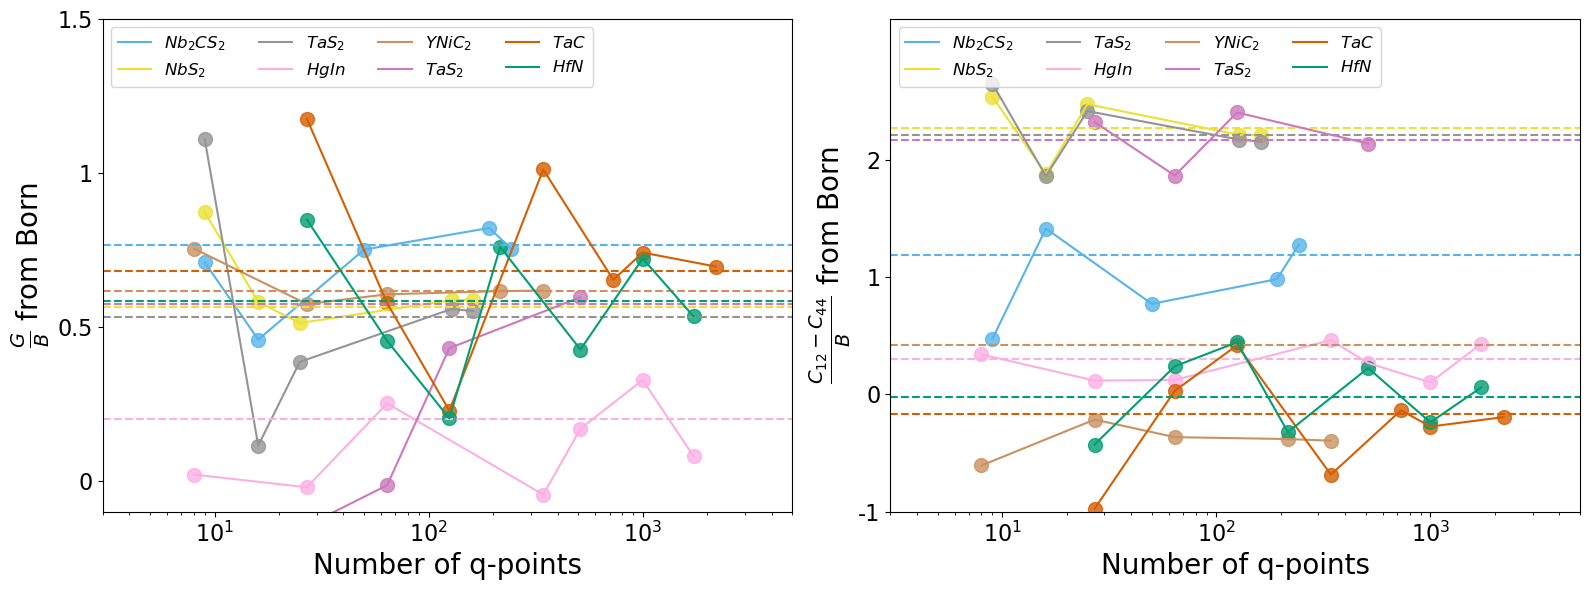

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(1, 2, figsize=(16, 6))
colors = sns.color_palette('colorblind', 10)

# for source, data in born.items():


# axs[0].legend(fontsize=16)
# axs[1].legend(fontsize=16)

# for id in structures_to_check:
for id in ['mpds-S1412199', 'mpds-S547970', 'icsd-200101', 'mpds-S1251782', 'mpds-S1830331', 'mpds-S529575', 'mpds-S534147', 'mpds-S1923735']:
    if id in unstable:
        continue
    plot_from_source(axs, id, color = colors.pop(), print_info=False)

axs[0].set_xlim(3, 5000)
axs[0].set_ylim(-0.1, 1.5)
axs[1].set_xlim(3, 5000)
axs[1].set_ylim(-1, 3.2)

axs[0].legend(fontsize=12, loc='upper left', ncol=4)
axs[1].legend(fontsize=12, loc='upper left', ncol=4)

fig.tight_layout()
fig.savefig('/home/yimzhang/Development/aiida/ductility/code/born/figs2.pdf')

In [57]:
def parse_phbands(file_content, kpoints = None):
    """Parse the contents of a band structure file generated by EPW software."""
    import re
    import numpy
    from aiida.orm import BandsData, KpointsData
    from math import ceil

    file_content = file_content.splitlines()
    nbnd, nks = (
        int(v)
        for v in re.search(r"&plot nbnd=\s+(\d+), nks=\s+(\d+)", file_content.pop(0)).groups()
    )

    kpts = []
    bands = []

    nline_frequencies = ceil(nbnd / 6)
    nblocks = len(file_content) // (nline_frequencies+1)

    for iblock in range(nblocks):
        line = file_content.pop(0)
        kpts.append(line.strip().split())
        band = []
        for iband in range(nline_frequencies):
            line = file_content.pop(0)
            band += line.strip().split()

        bands.append(band)

    kpts = numpy.array(kpts, dtype=float)
    bands = numpy.array(bands, dtype=float)
    if kpoints is None:
        kpoints_for_bands = KpointsData()
        kpoints_for_bands.set_kpoints(kpts)
    else:
        kpoints_for_bands = kpoints
    output_bands = orm.BandsData()
    output_bands.set_kpointsdata(kpoints_for_bands)
    output_bands.set_bands(bands, units='cm-1')

    return output_bands

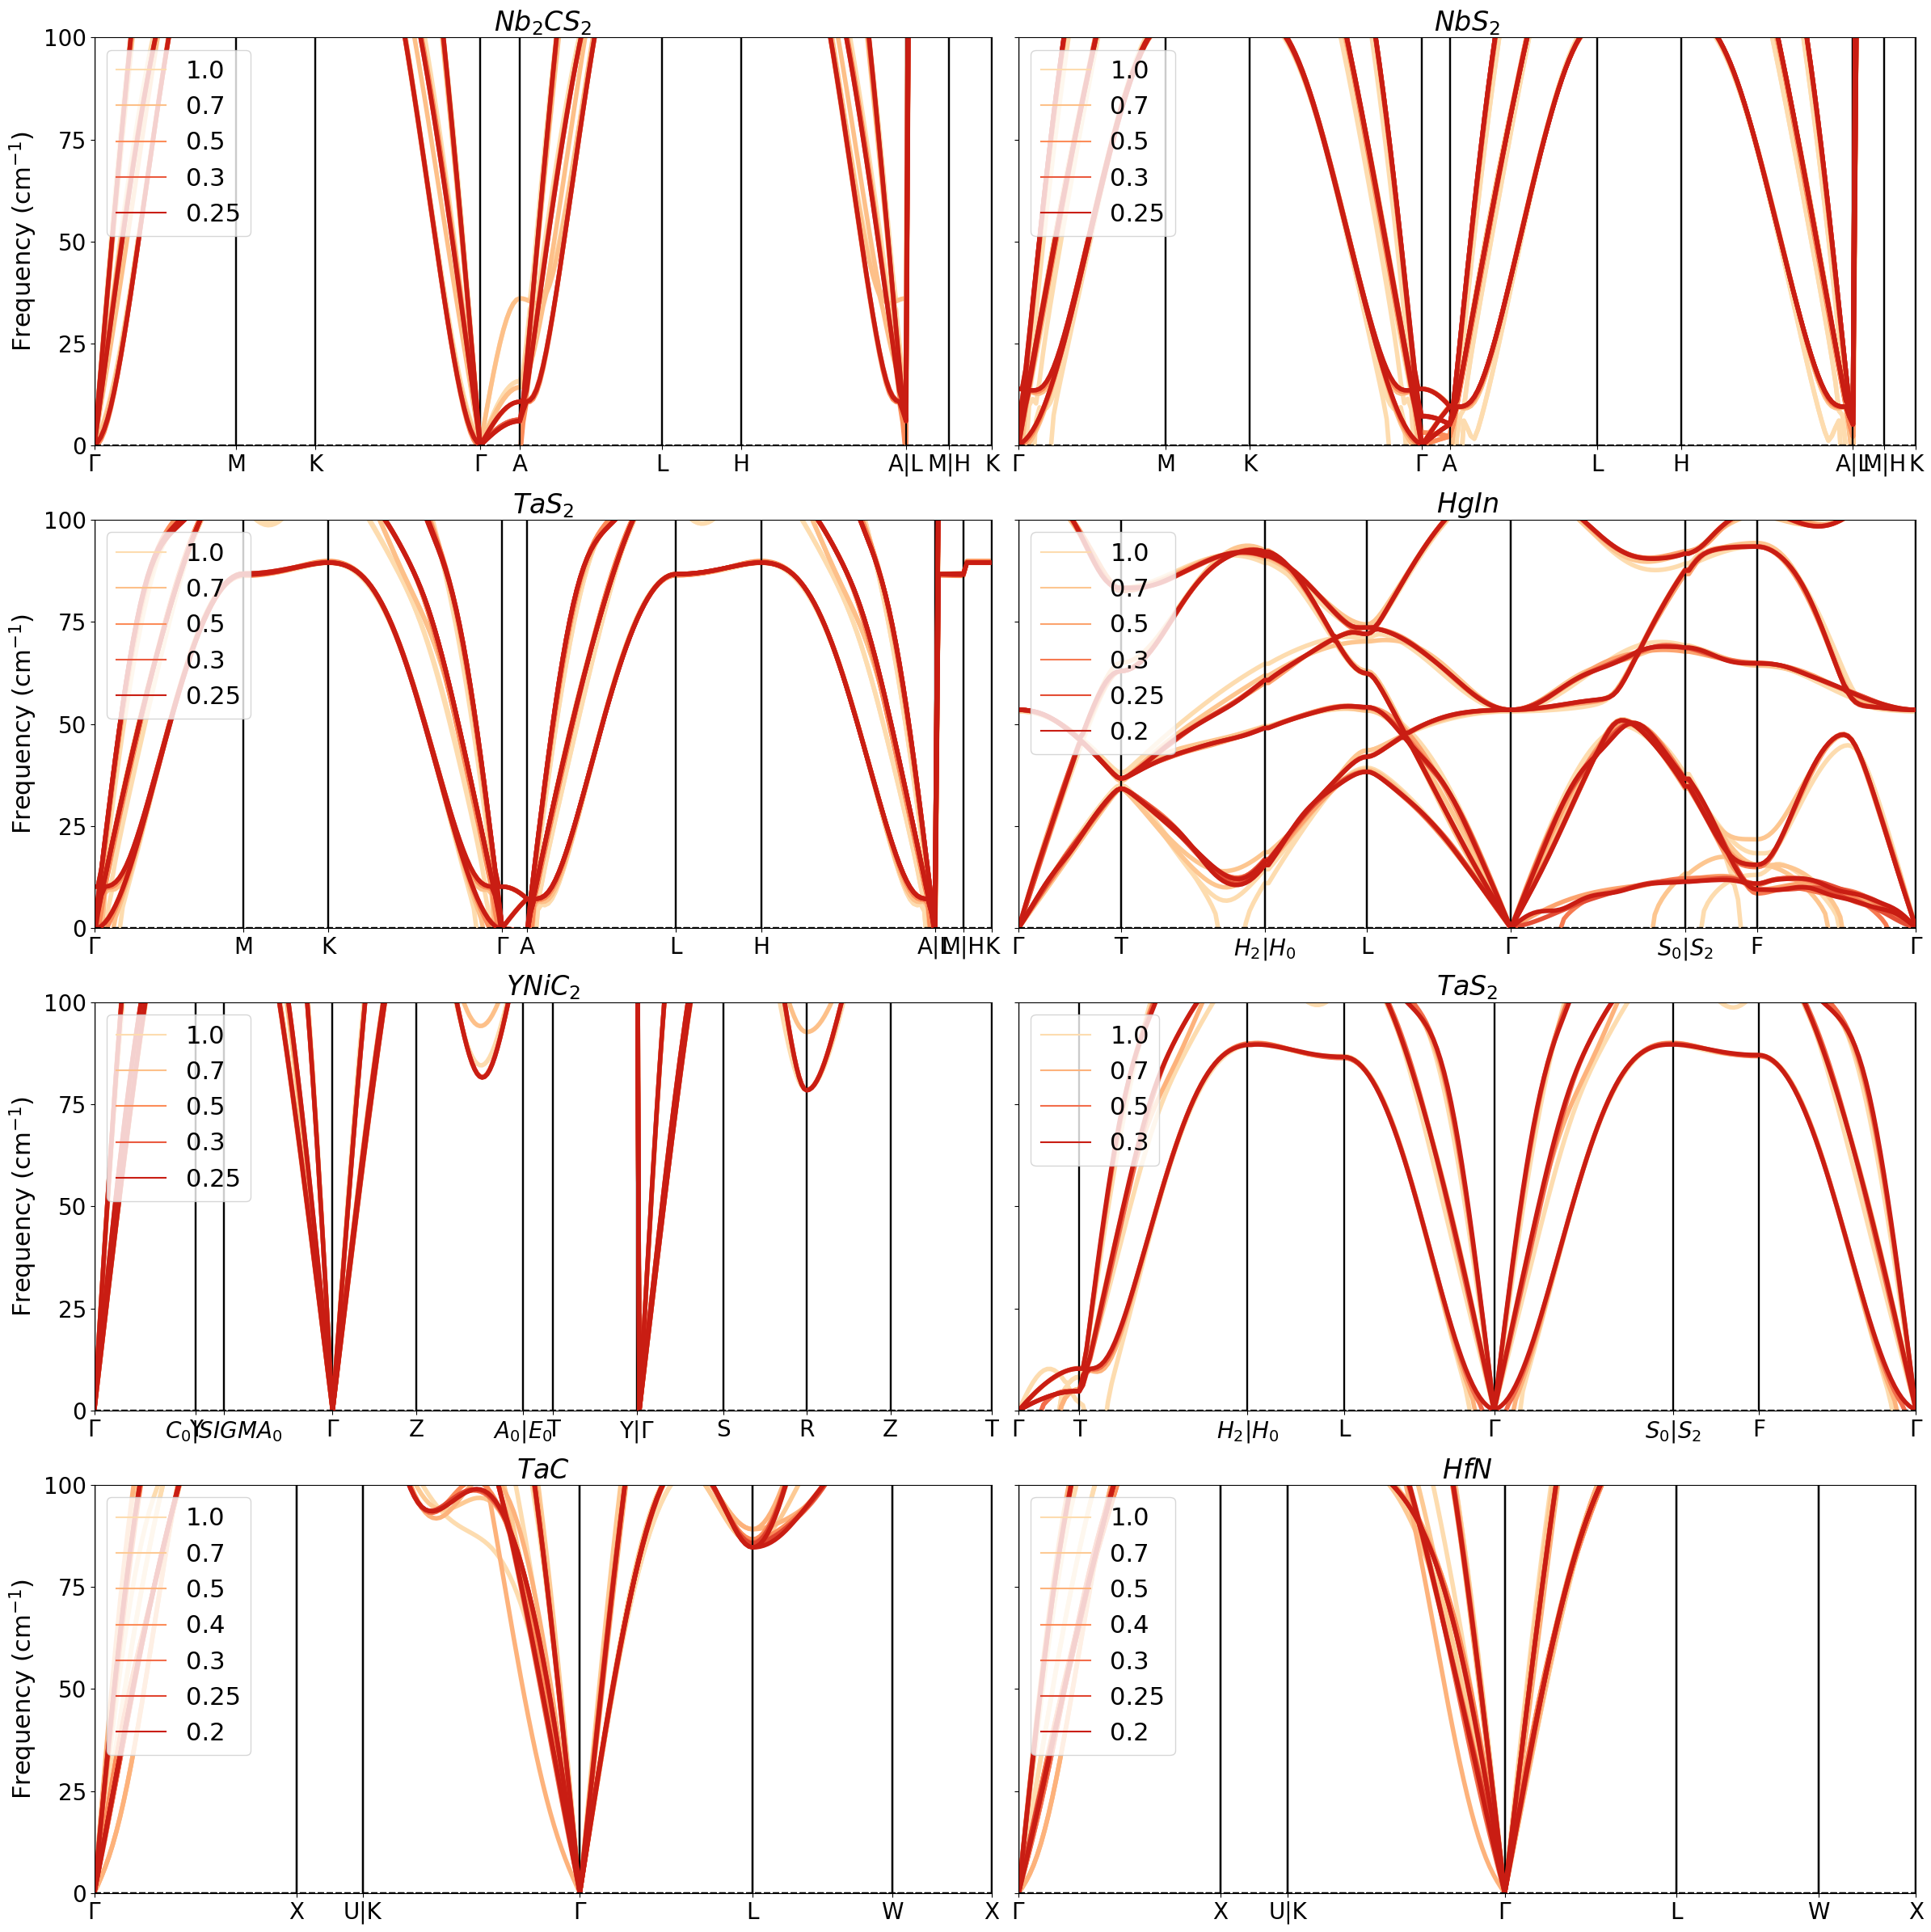

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(4, 2, figsize=(24, 24))
for (i, source), ax in zip(enumerate(
    ['mpds-S1412199', 'mpds-S547970', 'icsd-200101', 'mpds-S1251782', 'mpds-S1830331', 'mpds-S529575', 'mpds-S534147', 'mpds-S1923735']
    ), axs.flatten()):

    # colors = sns.color_palette('colorblind', 10)

    bands_datas = {}
    for path in (data_dir / source).glob('*'):
        matdyn_base_path = path / 'matdyn_base' / 'iteration_01' / 'phonon_frequencies.dat'
        if not matdyn_base_path.exists():
            continue
        structure = structures_to_check[source]
        inputs = {
            'reference_distance': orm.Float(0.025),
            'metadata': {'call_link_label': 'seekpath'},
        }
        result = seekpath_structure_analysis(structure, **inputs)
        kpoints = result['explicit_kpoints']
        bands_data = parse_phbands(matdyn_base_path.read_text(), kpoints=kpoints)
        bands_datas[path.name] = bands_data
        # if path.name not in ['0.7', '0.5', '1.0']:
        #     continue

    colors = plt.get_cmap('OrRd')(np.linspace(0.2, 0.8, len(bands_datas))).tolist()
    for (path_name, bands_data), color in zip(sorted(bands_datas.items(), reverse=True), colors):
        plot_bands(bands_data, axis=ax, color=color, label=path_name, tick_label_size=20, linewidth=4)

    ax.legend(loc='upper left', fontsize=22)
    ax.set_ylim(0, 100)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_yticklabels([0, 25, 50, 75, 100], fontsize=20)
    ax.set_title(formula_to_latex(formulae[source]), fontsize=24)
    ax.set_ylabel('Frequency (cm$^{-1}$)', fontsize=22)

for ax in axs[:, 1]:
    ax.set_ylabel('')
    ax.set_yticklabels([])

plt.tight_layout()
plt.savefig('/home/yimzhang/Development/aiida/ductility/code/born/figs3.pdf')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

colors = sns.color_palette('colorblind', 10)
fig, ax = plt.subplots(1, 1, figsize=(8, 6), sharex=True)
fig.patch.set_facecolor('white')
for qpoints_distance, data in born['mpds-S1251782'].items():
    print(qpoints_distance)
    if qpoints_distance not in [0.7, 0.5, 0.35 ]:
        continue
    plot_bands(
        data['phonon_bands'],
        seekpath_params=data['seekpath_parameters'],
        axis=ax,
        color=colors.pop(),
        # xlim=[0, 100],
        # ylim=[0, 2],
        label=f'{qpoints_distance} Å$^{{-1}}$',
        )

ax.legend()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

colors = sns.color_palette('colorblind', 10)
fig, ax = plt.subplots(1, 1, figsize=(8, 6), sharex=True)
fig.patch.set_facecolor('white')
for qpoints_distance, data in born['mpds-S1709373'].items():
    if qpoints_distance not in [0.2, 0.25]:
        continue
    plot_bands(
        data['phonon_bands'],
        seekpath_params=data['seekpath_parameters'],
        axis=ax,
        color=colors.pop(),
        xlim=[0, 100],
        ylim=[0, 6],
        label=f'{qpoints_distance} Å$^{{-1}}$',
        )

ax.legend()

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

colors = sns.color_palette('colorblind', 10)
fig, ax = plt.subplots(1, 1, figsize=(8, 6), sharex=True)
fig.patch.set_facecolor('white')
for qpoints_distance, data in born['icsd-44855'].items():
    # if qpoints_distance not in [0.5, 0.25]:
    #     continue
    plot_bands(
        data['phonon_bands'],
        seekpath_params=data['seekpath_parameters'],
        axis=ax,
        color=colors.pop(),
        # xlim=[0, 100],
        # ylim=[0, 5],
        label=f'{qpoints_distance} Å$^{{-1}}$',
        )

ax.legend()


	\hline
	$\mathbf{q}$ & $2^3$ & $4^3$ & $6^3$ & $8^3$ & $10^3$ & $12^3$ & DFT \\
	\hline
	$B$ & 126.0 & 440.0 & 277.3 & 372.6 & 252.8 & 415.3 & 323.7 \\
	$G$ & 103.5 & 256.4 & 230.0 & 259.6 & 211.2 & 251.0 & 223.5 \\
	$B/G$ & 1.217 & 1.715 & 1.206 & 1.435 & 1.197 & 1.654 & 1.447 \\
	\hline
	$\mathbf{q}$ & $14^3$ & $16^3$ & $18^3$ & & & & DFT \\
	$B$ & -- & 365.7 & 308.0 & & & & 323.7 \\
	$G$ & -- & 231.5 & 236.0 & & & & 223.5 \\
	$B/G$ & -- & 1.579 & 1.305 & & & & 1.447 \\




		$\mathbf{q}$ & $2^3$ & $4^3$ & $6^3$ & $8^3$ & $10^3$ & $12^3$ & DFT \\
		\hline
		$B$ & 61.2 & 330.5 & 238.6 & 332.0 & 206.2 & -- & 266.3 \\
		$G$ & 130.3 & 136.1 & 190.1 & 117.7 & 184.4 & -- & 140.9 \\
		$G/B$ & 0.470 & 2.429 & 1.255 & 2.821 & 1.118 & -- & 0.529 \\


### COLLECT RESULTS for convergence with FD

In [15]:
scon_group = orm.Group.collection.get(label='paper/structures/scon')
scon_sources = {}
for n in scon_group.nodes:
    source = f"{n.base.extras.all['source_db']}-{n.base.extras.all['source_id']}"
    scon_sources[source] = n

print(len(scon_sources))


250


In [16]:
from aiida.storage.sqlite_zip.backend import SqliteZipBackend
from pathlib import Path
from util import *

AIIDA_PROFILE_FOLDER = Path("/home/yimzhang/Development/aiida/ductility/archive")
ARCHIVE_QE_SCREENING = "ductility_thermo_pw_v3.aiida"
AIIDA_PROFILE_NAME = AIIDA_PROFILE_FOLDER / ARCHIVE_QE_SCREENING

archive_profile = SqliteZipBackend.create_profile(AIIDA_PROFILE_NAME)
fd = update_modulus_from_fd(archive_profile, 'ductility/thermo_pw/v3')

archive_profile = load_profile('ductility', allow_switch=True)

born_05 = update_modulus_from_born(archive_profile, 'ductility/born/supercon/ri')


298


In [17]:
fd = {
    key: value 
    for key, value in fd.items() 
    if key in scon_sources
}

In [18]:
cd_born_fd = compare(born_05, fd)
# cd_born_fd_converged = compare(MODULI['born'], MODULI['fd'], None)

In [33]:
from scipy import stats

def plot_comparison_fd_born(
    pugh_ratio, 
    modified_pettifor_ratio, 
    axs=None, 
    color='grey', 
    legend='', 
    addressed_points = None, 
    manual_offsets1 = None,
    manual_offsets2 = None,
    do_fit=False, 
    plot_diagonal=True, 
    labels = ['(a)', '(b)'],
    **kwargs
    ):
    if axs is None:
        import matplotlib.pyplot as plt
        fig, axs = plt.subplots(1, 2, figsize=(16, 8))

    common_bbox = dict(
        boxstyle='round,pad=1.5', 
        fc='white',          
        ec='none',            
        alpha=0.01,          
        lw=0
    )
    print(pugh_ratio['born'].shape)
    r, p_value = stats.pearsonr(pugh_ratio['born'], pugh_ratio['fd'])
    print(
        'Pearson correlation coefficient for pugh ratio:',
        r
        )

    r, p_value = stats.pearsonr(modified_pettifor_ratio['born'], modified_pettifor_ratio['fd'])
    print(
        'Pearson correlation coefficient for modified pettifor ratio:',
        r
        )

    axs[0].set_xlim(0, 1.3)
    axs[0].set_ylim(0, 1.3)
    axs[1].set_xlim(-1, 4)
    axs[1].set_ylim(-1, 4)

    axs[0].set_xlabel(r'$\frac{G}{B} \text{ from Born}$')
    axs[0].set_ylabel(r'$\frac{G}{B} \text{ from FD}$')
    axs[1].set_xlabel(r'$\frac{C_{12} - C_{44}}{B} \text{ from Born}$')
    axs[1].set_ylabel(r'$\frac{C_{12} - C_{44}}{B} \text{ from FD}$')

    axs[0].set_xticks([0, 0.5, 1])
    axs[0].set_yticks([0, 0.5, 1])
    axs[0].set_xticklabels([0, 0.5, 1])
    axs[0].set_yticklabels([0, 0.5, 1])
    axs[1].set_xticks([-1, 0, 1, 2, 3, 4])
    axs[1].set_yticks([-1, 0, 1, 2, 3, 4])
    axs[1].set_xticklabels([-1, 0, 1, 2, 3, 4])
    axs[1].set_yticklabels([-1, 0, 1, 2, 3, 4])

    if plot_diagonal:
        axs[0].plot([0, 1.3], [0, 1.3], color='black', linestyle='--',)
        axs[1].plot([-1, 4], [-1, 4], color='black', linestyle='--')

    axs[0].scatter(
        pugh_ratio['born'], 
        pugh_ratio['fd'], 
        s=100, 
        alpha=0.8,
        color=color,
        label=legend)
    axs[1].scatter(
        modified_pettifor_ratio['born'], 
        modified_pettifor_ratio['fd'], 
        s=100, 
        alpha=0.8,
        color=color,
        label=legend)

    if addressed_points is not None:
        axs[0].scatter(
            addressed_points['pugh_ratio']['born'],
            addressed_points['pugh_ratio']['fd'],
            s=100, 
            alpha=0.8,
            color='red'
            )
        axs[1].scatter(
            addressed_points['modified_pettifor_ratio']['born'], 
            addressed_points['modified_pettifor_ratio']['fd'], 
            s=100, 
            alpha=0.8,
            color='red'
            )
        texts = []
        for i, (x, y, label) in enumerate(zip(
            addressed_points['pugh_ratio']['born'],
            addressed_points['pugh_ratio']['fd'],
            addressed_points['formula']
            )):

            axs[0].annotate(
                label, 
                xy=(x, y),              # 点的坐标
                xytext=manual_offsets1[i] if manual_offsets1 else [0, 0], # 文字相对于点的偏移
                textcoords="offset points",
                fontsize=kwargs.get('formula_to_latexfontsize', 9),
                # fontfamily='serif', 
                # fontname='STIXGeneral',
                ha='center', va='center',
                bbox=None,
                # bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.8), # 统一美观的背景框
                arrowprops=dict(
                        arrowstyle='->, head_width=0.4, head_length=0.6', # 箭头样式
                        mutation_scale=8,
                        connectionstyle="arc3,rad=0.1", # 稍微带一点弧度，更有学术设计感
                        color='black',
                        lw=1.5,
                        shrinkA=2,           # 箭头末端离文字的距离
                        shrinkB=2,           # 箭头前端离数据点的距离
                        relpos=(0.5, 0.5)    # 箭头指向文字的中心点
                    )
                )

        for i, (x, y, label) in enumerate(zip(
            addressed_points['modified_pettifor_ratio']['born'],
            addressed_points['modified_pettifor_ratio']['fd'],
            addressed_points['formula']
            )):
            axs[1].annotate(
                label, 
                xy=(x, y),              # 点的坐标
                xytext=manual_offsets2[i] if manual_offsets2 else [0, 0], # 文字相对于点的偏移
                textcoords="offset points",
                fontsize=kwargs.get('formula_to_latexfontsize', 9),
                # fontfamily='serif', 
                # fontname='STIXGeneral',  # 关键：这里应该是 fontname 而不是 name
                ha='center', va='center',
                bbox=None,
                arrowprops=dict(
                    arrowstyle='->, head_width=0.4, head_length=0.6', # 箭头样式
                    mutation_scale=8,
                    connectionstyle="arc3,rad=0.1", # 稍微带一点弧度，更有学术设计感
                    color='black',
                    lw=1.5,
                    shrinkA=2,           # 箭头末端离文字的距离
                    shrinkB=2,           # 箭头前端离数据点的距离
                    relpos=(0.5, 0.5)    # 箭头指向文字的中心点
                    )
                )


    axs[0].text(0.02, 0.92, labels[0], 
                transform=axs[0].transAxes, 
                fontsize=28, 
                color='black',
                bbox=dict(facecolor='white', edgecolor='white', ))
    axs[1].text(0.02, 0.92, labels[1], 
                transform=axs[1].transAxes, 
                fontsize=28, 
                color='black',
                bbox=dict(facecolor='white', edgecolor='white', ))
    

    if do_fit:
        from sklearn.linear_model import LinearRegression
        X = pugh_ratio[:, 0].reshape(-1, 1)
        model = LinearRegression()
        model.fit(X, pugh_ratio[:, 1])
        m = model.coef_[0]
        b = model.intercept_
        y_pred = model.predict(X)
        axs[0].plot(X, y_pred, color='red')

        X = modified_pettifor_ratio[:, 0].reshape(-1, 1)
        model.fit(X, modified_pettifor_ratio[:, 1])
        m = model.coef_[0]
        b = model.intercept_
        y_pred = model.predict(X)
        axs[1].plot(X, y_pred, color='red')


In [25]:
manual_offsets = (
    [
        (35, 35),  # Nb2CS2
        (-40, 60),   # NbS2
        (-45, -10),   # TaS2 (1)
        (-15, -35), # HgIn
        (60, 120),  # YNiC2
        (60, 100), # TaS2 (2)
        (30, 100),   # TaC
        (10, 80)    # HfN
    ],
    [
    (30, 35),  # Nb2CS2
    (-20, 80),   # NbS2
    (30, -40),   # TaS2 (1)
    (10, -70), # HgIn
    (0, 40),  # YNiC2
    (-35, -45), # TaS2 (2)
    (20, -40),   # TaC
    (55, -5)    # HfN
    ],
    [
    (-30, -25), # HgIn (左下)
    (-25, 50),   # TaC (右上)
    (-45, 25),  # YNiC2 (左侧拉开)
    (40, -60),   # NbS2 (向上大幅拉开，避开堆叠)
    (-60, 0),   # HfN (向左水平拉开)
    (65, -10),   # TaS2 (1) (向右侧推)
    (-20, -60), # TaS2 (2) (向下躲避)
    (60, -15)   # Nb2CS2 (右下拉开)
    ],
    [
    (10, 45), # HgIn (左下)
    (25, -40),   # TaC (右上)
    (-5, 65),  # YNiC2 (左侧拉开)
    (10, 40),   # NbS2 (向上大幅拉开，避开堆叠)
    (60, 0),   # HfN (向左水平拉开)
    (65, 0),   # TaS2 (1) (向右侧推)
    (-60, 20), # TaS2 (2) (向下躲避)
    (50, -25)   # Nb2CS2 (右下拉开)
]
)

['$Nb_{2}CS_{2}$', '$NbS_{2}$', '$TaS_{2}$', '$HgIn$', '$YNiC_{2}$', '$TaS_{2}$', '$TaC$', '$HfN$']
(250,)
Pearson correlation coefficient for pugh ratio: 0.4705786533625811
Pearson correlation coefficient for modified pettifor ratio: 0.9004747492949017
mpds-S1251782 0.2
mpds-S534147 0.2
mpds-S1830331 0.25
mpds-S547970 0.25
mpds-S1923735 0.2
mpds-S529575 0.3
icsd-200101 0.25
mpds-S1412199 0.25
(8,)
Pearson correlation coefficient for pugh ratio: 0.9748309544371548
Pearson correlation coefficient for modified pettifor ratio: 0.9683169231490725
Pearson Correlation for last value for pugh ratio: 0.9748309544371548
Pearson Correlation for last value for modified pettifor ratio: 0.9683169231490726
Pearson Correlation for last value for modified pupettiforgh ratio without first material: 0.9654674477086644
Pearson Correlation for q=0.5 for pugh ratio: 0.9066094368798122
Pearson Correlation for q=0.5 for modified pugh ratio: 0.9840232021696854


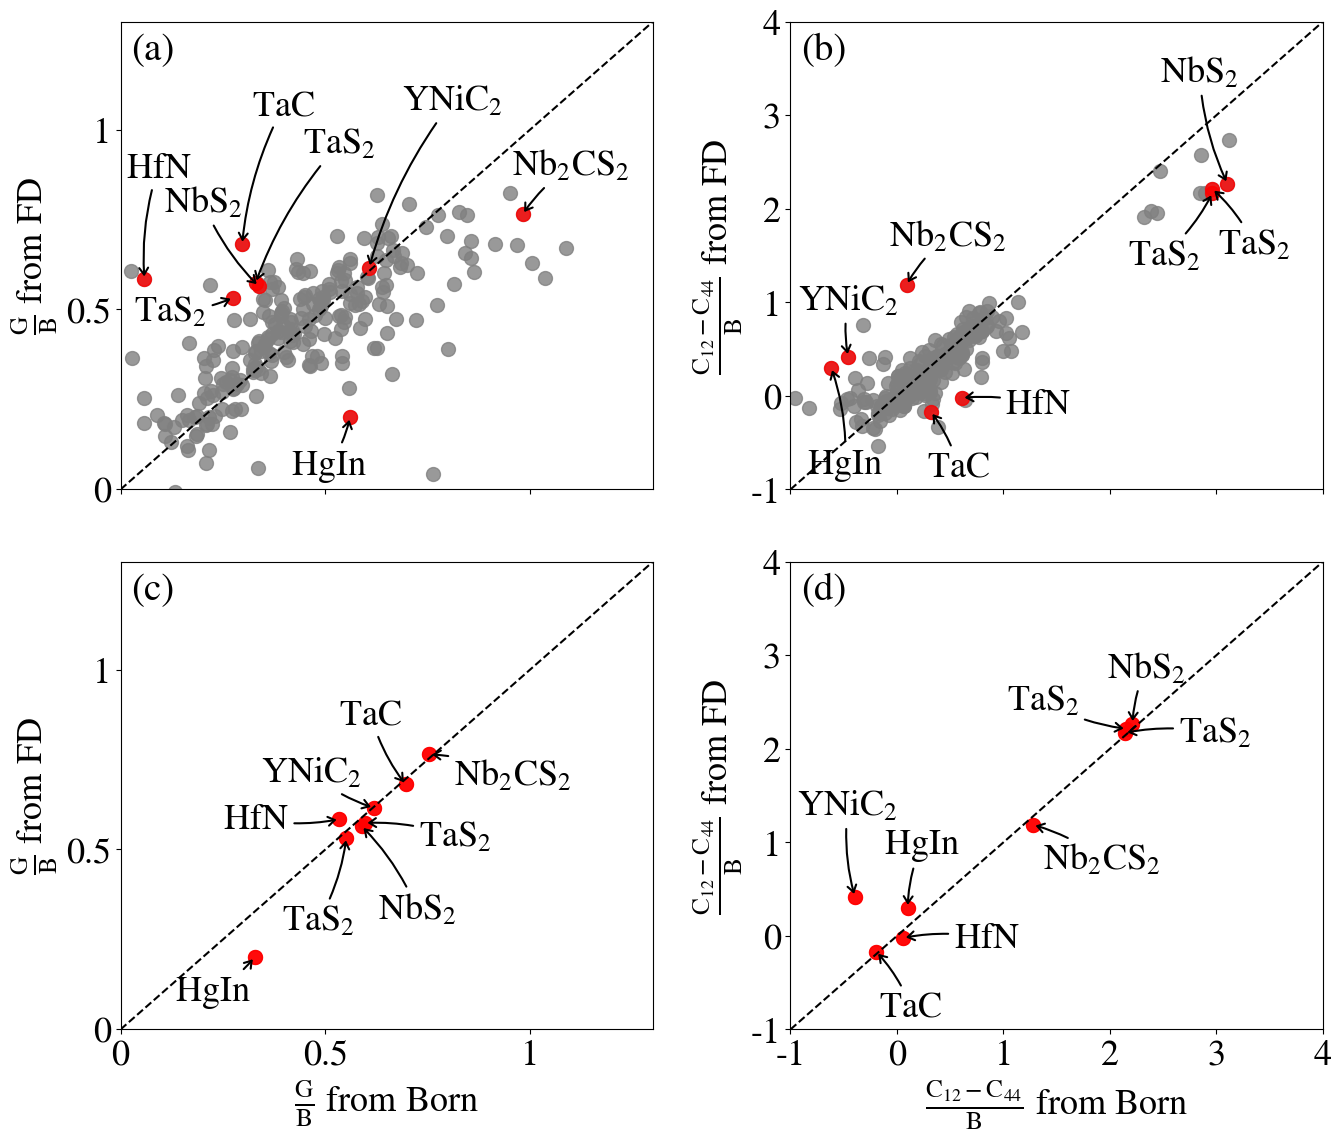

In [34]:
%matplotlib inline

def calculate_pearson_correlation(x, y):
    """
    Calculates the Pearson correlation coefficient (r_xy) based on the image formula.
    
    Args:
        x (list or np.array): First dataset
        y (list or np.array): Second dataset
        
    Returns:
        float: Pearson correlation coefficient
    """
    x = np.array(x)
    y = np.array(y)
    
    # n is the number of elements
    n = len(x)
    
    # Calculate means (x_bar and y_bar)
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    
    # Numerator: sum(xi * yi) - n * x_mean * y_mean
    numerator = np.sum(x * y) - (n * x_mean * y_mean)
    
    # Denominator: sqrt(sum(xi^2) - n * x_mean^2) * sqrt(sum(yi^2) - n * y_mean^2)
    term_x = np.sqrt(np.sum(x**2) - (n * x_mean**2))
    term_y = np.sqrt(np.sum(y**2) - (n * y_mean**2))
    denominator = term_x * term_y
    
    if denominator == 0:
        return 0  # Avoid division by zero if there's no variation
        
    return numerator / denominator

from matplotlib import pyplot as plt
import numpy as np

from matplotlib.font_manager import fontManager

plt.rcParams.update({'font.size': 26})
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['STIXGeneral']
plt.rcParams['mathtext.fontset'] = 'stix' 
# 让非公式的文字也默认使用 STIXGeneral
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['mathtext.default'] = 'regular'

# plt.close('all')
addressed_points = {
    'pugh_ratio': {
        'born': [],
        'fd': [],
        },
    'modified_pettifor_ratio': {
        'born': [],
        'fd': [],
        },
    'formula': [],
}

for source in ['mpds-S1412199', 'mpds-S547970', 'icsd-200101', 'mpds-S1251782', 'mpds-S1830331', 'mpds-S529575', 'mpds-S534147', 'mpds-S1923735']:
    addressed_points['pugh_ratio']['born'].append(born_05[source]['VRH_average']['pugh_ratio'])
    addressed_points['pugh_ratio']['fd'].append(fd[source]['VRH_average']['pugh_ratio'])
    addressed_points['modified_pettifor_ratio']['born'].append(born_05[source]['VRH_average']['modified_pettifor_ratio'])
    addressed_points['modified_pettifor_ratio']['fd'].append(fd[source]['VRH_average']['modified_pettifor_ratio'])
    addressed_points['formula'].append(formula_to_latex(formulae[source]))
print(addressed_points['formula'])

fig, axs = plt.subplots(2, 2, figsize=(14, 12))
plot_comparison_fd_born(
    {'born': np.array(cd_born_fd['VRH_average']['pugh_ratio'])[:, 0], 'fd': np.array(cd_born_fd['VRH_average']['pugh_ratio'])[:, 1]}, 
    {'born': np.array(cd_born_fd['VRH_average']['modified_pettifor_ratio'])[:, 0], 'fd': np.array(cd_born_fd['VRH_average']['modified_pettifor_ratio'])[:, 1]},
    axs[0],
    addressed_points = addressed_points,
    manual_offsets1 = manual_offsets[0],
    manual_offsets2 = manual_offsets[1],
    labels = ['(a)', '(b)'],
    formula_to_latexfontsize=26,
    ax=axs[1],
    )


pugh_ratio_fd = []
pugh_ratio_last = []
modified_pettifor_ratio_fd = []
modified_pettifor_ratio_last = []

addressed_points = {
    'pugh_ratio': {
        'born': [],
        'fd': [],
        },
    'modified_pettifor_ratio': {
        'born': [],
        'fd': [],
        },
    'formula': [],
}



for source, data in born.items():
    if source not in ['mpds-S1412199', 'mpds-S547970', 'icsd-200101', 'mpds-S1251782', 'mpds-S1830331', 'mpds-S529575', 'mpds-S534147', 'mpds-S1923735']:
        continue
    # qpoints_distance = min(data)
    descending_dict = {k: data[k] for k in sorted(data, reverse=False)}
    for key, value in descending_dict.items():
        VRH_average = value.get('VRH_average')
        if not VRH_average:
            continue
        qpoints_distance = key
        break
    print(source, qpoints_distance)
    pugh_ratio_fd.append(fd[source]['VRH_average']['pugh_ratio'])
    pugh_ratio_last.append(data[qpoints_distance]['VRH_average']['pugh_ratio'])
    modified_pettifor_ratio_fd.append(fd[source]['VRH_average']['modified_pettifor_ratio'])
    modified_pettifor_ratio_last.append(data[qpoints_distance]['VRH_average']['modified_pettifor_ratio'])

    addressed_points['pugh_ratio']['born'].append(data[qpoints_distance]['VRH_average']['pugh_ratio'])
    addressed_points['pugh_ratio']['fd'].append(fd[source]['VRH_average']['pugh_ratio'])
    addressed_points['modified_pettifor_ratio']['born'].append(data[qpoints_distance]['VRH_average']['modified_pettifor_ratio'])
    addressed_points['modified_pettifor_ratio']['fd'].append(fd[source]['VRH_average']['modified_pettifor_ratio'])
    addressed_points['formula'].append(formula_to_latex(formulae[source]))



plot_comparison_fd_born(
    {'fd': np.array(pugh_ratio_fd), 'born': np.array(pugh_ratio_last)},
    {'fd': np.array(modified_pettifor_ratio_fd), 'born': np.array(modified_pettifor_ratio_last)},
    axs[1],
    addressed_points = addressed_points,
    manual_offsets1 = manual_offsets[2],
    manual_offsets2 = manual_offsets[3],
    color='red',
    labels = ['(c)', '(d)'],
    formula_to_latexfontsize=26,
    )

covariance_matrix = np.cov(pugh_ratio_fd, pugh_ratio_last)
covariance = covariance_matrix[0, 1]

# 计算皮尔逊相关系数 (Pearson Correlation)
correlation_matrix = np.corrcoef(pugh_ratio_fd, pugh_ratio_last)
correlation = correlation_matrix[0, 1]
print("Pearson Correlation for last value for pugh ratio:", correlation)


covariance_matrix = np.cov(modified_pettifor_ratio_fd, modified_pettifor_ratio_last)
covariance = covariance_matrix[0, 1]

# 计算皮尔逊相关系数 (Pearson Correlation)

modified_pettifor_ratio_fd = [0.3019710001278281, -0.17049468877598722, 0.4194468782702578, 2.2669819367722677, -0.022362960959083376, 2.168917483099002, 2.212726483760252, 1.1866056795717612]
modified_pettifor_ratio_last = [0.10106009813172741, -0.1948000261078704, -0.39599560433347947, 2.211120024850328, 0.05807660909000708, 2.1374656483499246, 2.1538363020328357, 1.2755257643887687]

correlation_matrix = np.corrcoef(modified_pettifor_ratio_fd, modified_pettifor_ratio_last)
correlation = correlation_matrix[0, 1]
print("Pearson Correlation for last value for modified pettifor ratio:", calculate_pearson_correlation(
    modified_pettifor_ratio_fd, modified_pettifor_ratio_last))

modified_pettifor_ratio_fd = [ -0.17049468877598722, 0.4194468782702578, 2.2669819367722677, -0.022362960959083376, 2.168917483099002, 2.212726483760252, 1.1866056795717612]
modified_pettifor_ratio_last = [ -0.1948000261078704, -0.39599560433347947, 2.211120024850328, 0.05807660909000708, 2.1374656483499246, 2.1538363020328357, 1.2755257643887687]
print("Pearson Correlation for last value for modified pupettiforgh ratio without first material:", calculate_pearson_correlation(
    modified_pettifor_ratio_fd, modified_pettifor_ratio_last))


pugh_ratio_fd = []
pugh_ratio_05 = []
modified_pettifor_ratio_fd = []
modified_pettifor_ratio_05 = []

for source, data in born.items():
    if source not in  ['mpds-S1412199', 'mpds-S547970', 'icsd-200101', 'mpds-S1251782', 'mpds-S1830331', 'mpds-S529575']:
        continue
    if 0.5 in data:
        pugh_ratio_fd.append(fd[source]['VRH_average']['pugh_ratio'])
        pugh_ratio_05.append(data[0.5]['VRH_average']['pugh_ratio'])
        modified_pettifor_ratio_fd.append(fd[source]['VRH_average']['modified_pettifor_ratio'])
        modified_pettifor_ratio_05.append(data[0.5]['VRH_average']['modified_pettifor_ratio'])


covariance_matrix = np.cov(pugh_ratio_fd, pugh_ratio_05)
covariance = covariance_matrix[0, 1]

# 计算皮尔逊相关系数 (Pearson Correlation)
correlation_matrix = np.corrcoef(pugh_ratio_fd, pugh_ratio_05)
correlation = correlation_matrix[0, 1]
print("Pearson Correlation for q=0.5 for pugh ratio:", correlation)


covariance_matrix = np.cov(modified_pettifor_ratio_fd, modified_pettifor_ratio_05)
covariance = covariance_matrix[0, 1]

# 计算皮尔逊相关系数 (Pearson Correlation)
correlation_matrix = np.corrcoef(modified_pettifor_ratio_fd, modified_pettifor_ratio_05)
correlation = correlation_matrix[0, 1]
print("Pearson Correlation for q=0.5 for modified pugh ratio:", correlation)


axs[0, 0].set_xlabel('')
axs[0, 1].set_xlabel('')
axs[0, 0].set_xticklabels([])
axs[0, 1].set_xticklabels([])

for text_obj in fig.findobj(plt.Text):
    text_obj.set_fontfamily('serif')
    text_obj.set_fontname('STIXGeneral') # 或者 'Times New Roman'
    
fig.tight_layout()
fig.savefig('/home/yimzhang/Development/aiida/ductility/data/elastic/fig1.pdf', dpi=800)

### CONVERGENCE ON KPOINTS AND SMEARING

In [10]:
unstable_qpoints = {
    'mpds-S1251782': [0.0, 0.1, -0.1],
    'mpds-S1503730': [0.0, 0.0, 2/7],
    'mpds-S301111': [0.0, 0.3, 0.0],
    'mpds-S549446': [0.0, 1/3, 1/3],
    'mpds-S551694': [0.0, 0.3, 0.0],
}

In [11]:
lucia_computer = orm.load_computer('lucia')
lucia_computer.set_workdir(f'/gpfs/scratch/acad/elph/yimzhang/aiida_workdir/ductility/born/check_convergence')


In [13]:
def recursive_set(obj, target_key, new_value):
    """
    This function recursively traverses a nested dictionary or list and sets the value of target_key to new_value.
    This function will directly modify the original object (in-place modification).

    params:
    obj (dict): The nested dictionary or list to operate on.
    target_key (any): The key you want to find and modify.
    new_value (any): The new value you want to set.
    """

    from collections.abc import MutableMapping
    if isinstance(obj, (MutableMapping, orm.Dict)):
        for key, value in obj.items():
            if key == target_key:
                obj[key] = new_value
            elif isinstance(value, (MutableMapping, orm.Dict)):
                recursive_set(value, target_key, new_value)

In [27]:

source = 'mpds-S551694'

check_convergence_label = f'ductility/born/workchains/check_convergence/{source}'
check_convergence_group, _ = orm.Group.collection.get_or_create(label=check_convergence_label)


In [ ]:
import itertools

structure = structures_to_check[source]
# for structure in selected_structures:
    # if count_submit >= num_submit:
    #     print(f'{count_submit} jobs submitted')
    #     break
extras = structure.base.extras.all

source = f'{extras["source_db"]}-{extras["source_id"]}'
# if source in workchains_in_half_heusler_v1:
#     print(f'{source} already in current_workchains')
#     continue

print(f'Submitting {source}')

for degauss in [0.02]:
    for kpoints_distance in [0.15, 0.13, 0.1, 0.08, 0.07]:
        builder = PwRelaxWorkChain.get_builder_from_protocol(
            code=codes['pw'],
            structure=structure,
            overrides=overrides.get("relax"),
        )
        builder.pop('base_init_relax')
        recursive_set(builder, 'kpoints_distance', orm.Float(kpoints_distance))
        recursive_set(builder, 'degauss', degauss)
        builder.clean_workdir = orm.Bool(False)
        wc = engine.submit(builder)
        wc.base.extras.set_many(
            {
                'source_db': extras['source_db'],
                'source_id': extras['source_id'],
                'kpoints_distance': kpoints_distance,
                'degauss': degauss,
                }
            )
        check_convergence_group.add_nodes(wc)



Submitting mpds-S1503730


/home/yimzhang/Software/apps/miniconda3/envs/aiida264/lib/python3.11/site-packages/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: base_relax.pseudo_family
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Software/apps/miniconda3/envs/aiida264/lib/python3.11/site-packages/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: base_init_relax.pseudo_family
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Software/apps/miniconda3/envs/aiida264/lib/python3.11/site-packages/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: base_relax.pseudo_family
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Software/apps/miniconda3/envs/aiida264/lib/python3.11/site-packages/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarnin

In [21]:
ph_done = []

for process in check_convergence_group.nodes:
    if process.process_label != 'PhBaseWorkChain':
        continue
    extras = process.base.extras.all

    ph_done.append(
        (extras['source_db'], extras['source_id'], extras['kpoints_distance'], extras['degauss']))


ph_done

[('mpds', 'S551694', 0.15, 0.01),
 ('mpds', 'S551694', 0.13, 0.01),
 ('mpds', 'S551694', 0.1, 0.01),
 ('mpds', 'S551694', 0.08, 0.01),
 ('mpds', 'S551694', 0.07, 0.01),
 ('mpds', 'S551694', 0.15, 0.03),
 ('mpds', 'S551694', 0.13, 0.03),
 ('mpds', 'S551694', 0.1, 0.03),
 ('mpds', 'S551694', 0.08, 0.03),
 ('mpds', 'S551694', 0.07, 0.03),
 ('mpds', 'S551694', 0.15, 0.04),
 ('mpds', 'S551694', 0.13, 0.04),
 ('mpds', 'S551694', 0.1, 0.04),
 ('mpds', 'S551694', 0.08, 0.04),
 ('mpds', 'S551694', 0.07, 0.04)]

In [22]:
count_submit = 0
num_submit = 50
for node in check_convergence_group.nodes:
    if node.process_label != 'PwRelaxWorkChain':
        continue

    if not node.is_finished_ok:
        continue

    if count_submit >= num_submit:
        break

    extras = node.base.extras.all

    mark = (extras['source_db'], extras['source_id'], extras['kpoints_distance'], extras['degauss'])
    if mark in ph_done:
        print(f'{mark} already done')
        continue

    qpoints = orm.KpointsData()
    qpoints.set_cell_from_structure(node.outputs.output_structure)
    qpoints.set_kpoints([unstable_qpoints[source]], cartesian=False)

    builder = PhBaseWorkChain.get_builder_from_protocol(
        code=codes['ph'],
        overrides=overrides.get("ph_base"),
        parent_folder = node.outputs.remote_folder
    )

    builder.qpoints = qpoints
    count_submit += 1

    wc = engine.submit(builder)
    wc.base.extras.set_many(
        extras
        )

    check_convergence_group.add_nodes(wc)

('mpds', 'S551694', 0.15, 0.01) already done
('mpds', 'S551694', 0.13, 0.01) already done
('mpds', 'S551694', 0.1, 0.01) already done
('mpds', 'S551694', 0.08, 0.01) already done
('mpds', 'S551694', 0.07, 0.01) already done
('mpds', 'S551694', 0.15, 0.03) already done
('mpds', 'S551694', 0.13, 0.03) already done
('mpds', 'S551694', 0.1, 0.03) already done
('mpds', 'S551694', 0.08, 0.03) already done
('mpds', 'S551694', 0.07, 0.03) already done
('mpds', 'S551694', 0.15, 0.04) already done
('mpds', 'S551694', 0.13, 0.04) already done
('mpds', 'S551694', 0.1, 0.04) already done
('mpds', 'S551694', 0.08, 0.04) already done
('mpds', 'S551694', 0.07, 0.04) already done


In [28]:


data_dir = Path(f'/home/yimzhang/Development/aiida/ductility/data/elastic/born/check_convergence/{source}')
data_dir.mkdir(parents=True, exist_ok=True)

results = NestedDict()
for node in check_convergence_group.nodes:
    if node.process_label != 'PwRelaxWorkChain':
        continue
    if not node.is_finished_ok:
        continue
    analyser = PwRelaxWorkChainAnalyser(node)
    extras = node.base.extras.all
    dest = data_dir / f"{source}" / str(extras['degauss']) / str(extras['kpoints_distance']) / 'pw_relax'
    analyser.copy_tree(dest)
for node in check_convergence_group.nodes:
    if node.process_label != 'PhBaseWorkChain':
        continue
    if not node.is_finished_ok:
        continue
    analyser = PhBaseWorkChainAnalyser(node)
    extras = node.base.extras.all
    degauss = extras['degauss']
    kpoints_distance = extras['kpoints_distance']
    number_of_kpoints = numpy.prod(
        node.inputs.ph.parent_folder.creator.outputs.output_parameters.get("monkhorst_pack_grid")
    )
    # results[degauss][kpoints_distance] = node.outputs.output_parameters.get('dynamical_matrix_1').get('frequencies')[0]
    results[degauss][number_of_kpoints] = node.outputs.output_parameters.get('dynamical_matrix_1').get('frequencies')[0]
    # dest = data_dir / f"{source}" / str(extras['degauss']) / str(extras['kpoints_distance']) / 'ph_base'
    # analyser.copy_tree(dest)


Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/elastic/born/check_convergence/mpds-S551694/mpds-S551694/0.01/0.15/pw_relax
Extraction complete.
Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/elastic/born/check_convergence/mpds-S551694/mpds-S551694/0.01/0.13/pw_relax
Extraction complete.
Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/elastic/born/check_convergence/mpds-S551694/mpds-S551694/0.01/0.1/pw_relax
Extraction complete.
Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/elastic/born/check_convergence/mpds-S551694/mpds-S551694/0.01/0.08/pw_relax
Extraction complete.
Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/elastic/born/check_convergence/mpds-S551694/mpds-S551694/0.01/0.07/pw_relax
Extraction complete.
Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/elastic/born/check_conve

In [14]:
results

NestedDict({0.01: NestedDict({2744: -5.515969, 4096: 16.980022, 8000: 3.263347, 15625: -6.653491, 24389: 2.763816}), 0.03: NestedDict({2744: -1.272709, 4096: 9.097599, 8000: 3.665695, 15625: 4.1574, 24389: 3.648532}), 0.04: NestedDict({2744: 4.583027, 4096: 6.566082, 8000: 4.407793, 15625: 4.439669})})

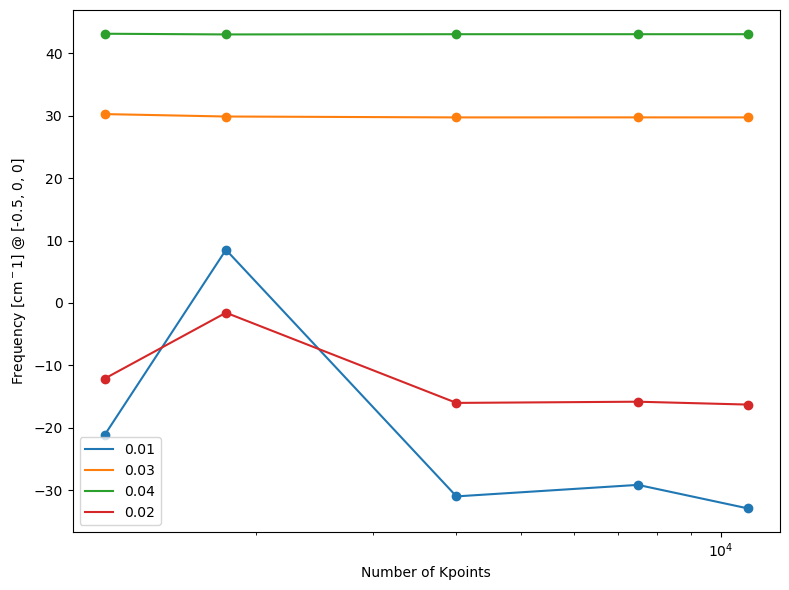

In [29]:
import re
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

for degauss, degauss_dict in results.items():
    sorted_degauss_dict = dict(sorted(degauss_dict.items()))
    ax.scatter(list(sorted_degauss_dict.keys()), list(sorted_degauss_dict.values()))
    ax.plot(list(sorted_degauss_dict.keys()), list(sorted_degauss_dict.values()), label=degauss)

ax.set_xlabel('Number of Kpoints')
ax.set_ylabel(f'Frequency [cm$^{-1}$] @ [-0.5, 0, 0]')
ax.legend()
ax.set_xscale('log')
fig.tight_layout()